# 2025 project

This notebook contains the assignment for part 1 (ECG) of the project of BDP of 2025 in Python.

## General remarks

First and foremost: **read the assignment description carefully**. There is plenty of information in the description that is relevant for both the implementation and oral defence. Your notebooks should produce all the desired plots/output with one click of the ‘run’-button! Document your code to facilitate debugging, reuse, and evaluation (in case of problems). We have provided code skeletons for both parts of the project to get you started. We strongly encourage you to use them and to keep the general structure of the skeleton intact.

You must generate all plots, tables... that are asked for in the Deliverables. Make sure that all plots are intelligible, contain proper axis labels, have titles...You are allowed and encouraged to reuse your code of the exercise sessions, however, we repeat that it is forbidden to share code between different teams and that automatically generated code should be properly referenced. We further refer to the rules on code/software plagiarism on Toledo.

Even if you're stuck on any part of the assignment, you can still proceed to the next parts of the assignment.

## Evaluation

You can complete the assignment alone or in a group of 2. You will need to submit (as a team):


*   your full Python code,
*   a filled-out version of the attached overview sheet.

Please upload your code and overview sheet on Toledo at the latest on **Saturday December 13th, at 23:59**. Do **not** include data and packages or scripts we provided, but only the files you wrote or modified. Make sure that your script produces all plots and results required in the assignment, as listed in the ‘Deliverables’. The exemplary interpretation questions mentioned in the assignment reflect the type of questions that might be asked on the oral evaluation.

The project will be evaluated *individually* during the oral examination on Wednesday/Thursday the 17th/18th of December. You will be asked questions about all parts of the project. Make sure you understand all methods that you use, even if you did not implement the code for that method yourself.



## 1. ECG-based identification

### Background

Robust identification is crucial to regulate who has access to a vault, a laptop, sensitive data... While passwords used to be the go-to method to identify a person, it becomes more and more apparent that they are too vulnerable to human weaknesses, such as people re-using the same password
everywhere or using passwords that are easily guessable. The speed and availability of biometrics such as iris, face and fingerprint scans have therefore provided a robust alternative for identification. However, these biometrics are all relatively simple to recreate (called spoofing) without the subject noticing this [1].

To combat these issues, ECG has gained a lot of attention in recent years as a biometric for identification. Similar to our face and fingerprint, our ECG is highly individual. Furthermore, it is much harder to recreate someone’s ECG than, e.g., someone’s face, since 1) it is much harder to record someone’s ECG without them noticing than it is taking pictures of them and 2) ECG is a
time signal, which is much harder to recreate than a static signal such as a mask of someone’s face [1]. Finally, the recent inclusion of ECG sensors in (nearly) all smartwatches made ECG broadly available as a biometric.

[1] M. Ingale, R. Cordeiro, S. Thentu, Y. Park, and N. Karimian, “ECG biometric authentication: A comparative analysis,” *IEEE Access*, vol. 8, pp. 117 853–117 866, 2020

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import scipy
import pywt
from matplotlib.axes import Axes
from scipy.fft import fft, ifft, fftshift
from typing import List, Optional, Union
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.signal import welch
from collections import Counter
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from itertools import permutations
import os

# RETAKE CHANGE: a single global seed replaces the unseeded `random` module that was
# used for the 20 s display window. The assignment requires the notebook to produce
# all figures with one click of "run"; with an unseeded RNG the figures changed on
# every execution and no longer matched the ones quoted in the report. See report S1.3.
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# RETAKE CHANGE (NEW): every deliverable figure is written to report/figures so the
# report and the notebook can never drift apart.
FIGDIR = os.path.join("..", "report", "figures")
os.makedirs(FIGDIR, exist_ok=True)

def save_fig(fig, name):
    """Save a figure as PDF (vector) for inclusion in the LaTeX report."""
    fig.savefig(os.path.join(FIGDIR, name + ".pdf"), bbox_inches="tight")

### 1.1 Data exploration

We simulated the real-life scenario where different people attempt to gain access to a single device by allowing the device to briefly measure their ECG (only a single heartbeat was measured at once). The device continuously measures a single channel of ECG, no matter whether someone is actually
touching the sensor or not. You thus get a single continuous signal that contains the ECG of multiple different people. The measured signal is approximately 10 min long and sampled at fs = 200 Hz. In total, five different subjects attempted to gain access to the device multiple times in a random
order. Subjects 1,2,4 and 5 are completely healthy, while Subject 3 suffers from valvular heart disease (meaning that one or more heart valves don’t open or close properly).

We already cleaned up the signal such that long pauses where the sensor did not measure a single heartbeat, are removed. Furthermore, we also removed heartbeats that were only partially measured (i.e. where a subject started measuring their ECG in the middle of the heartbeat). Because each subject only measured their ECG for a single heartbeat, there is no guarantee at all that two
consecutive heartbeats come from the same person, no matter how close they are to each other.

Every sample in the signal also has a corresponding label, indicating which of the five subjects was touching the sensor at each moment in time. **These labels only serve to evaluate the performance of your algorithm and to explore the data (when we explicitly ask you to do so). The identification algorithm itself must be completely unsupervised.**

This ECG data was originally recorded in the Physikalish-Technische Bundesanstalt, Berlin [2] and made publically available on Physionet. The signals were adapted for use in this project.

[2] R. Bousseljot, D. Kreiseler, and A. Schnabel, “Nutzung der EKG-Signaldatenbank CARDIODAT der PTB über das Internet,” *Biomedizinische Technik / Biomedical Engineering*, vol. 40, no. s1, pp. 317–318, jan 1995.

In [2]:
signal = np.load("ecg_signal.npz")
print(signal.keys())
ecg = signal['ecg']
print(f"The ECG shape is {ecg.shape}.")
fs = int(signal['fs'])
print(type(fs))
print(f"The sampling frequency is {fs} Hz.")
labels = signal['labels']
print(f"The labels' shape is {labels.shape}.")

KeysView(<numpy.lib.npyio.NpzFile object at 0x0000029741F0F4F0>)
The ECG shape is (121006,).
<class 'int'>
The sampling frequency is 200 Hz.
The labels' shape is (121006,).


Plot a random window of 20s of the raw ECG signal. Inspect which noise sources have infected the signal (if any). The noise is stationary, so it suffices to inspect a single segment to identify the noise sources.

In [3]:
def plot_ecg_time(
    signal: npt.NDArray[np.float64],
    fs: Union[int, float],
    ax: Axes,
    label: Optional[str] = None,
    linewidth: Union[int, float] = 1,
) -> None:
    n = len(signal)
    t = n/fs
    time = np.linspace(0, t, n)
    ax.plot(time, signal, label=label, linewidth=linewidth)

start sample: 10442
end sample: 14442


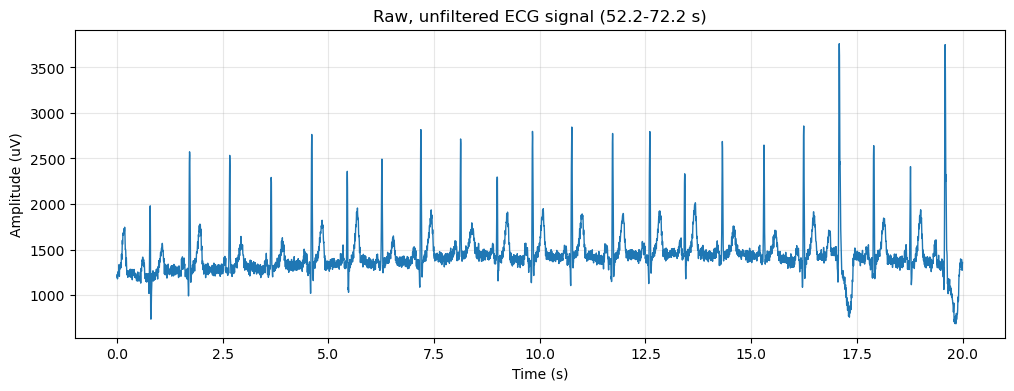

In [4]:
# plot 20 s
# RETAKE CHANGE: the window start is now drawn from the seeded generator `rng`
# (previously `random.randint`, unseeded) so this figure is reproducible.
fig, ax = plt.subplots(figsize=(12, 4))

duration = 20
window_length = int(duration * fs)
max_start_sample = len(ecg) - window_length

start_sample = int(rng.integers(0, max_start_sample))
end_sample = start_sample + window_length
print("start sample:", start_sample)
print("end sample:", end_sample)

ec_window = ecg[start_sample:end_sample]
plot_ecg_time(ec_window, fs, ax)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (uV)")
ax.set_title(f"Raw, unfiltered ECG signal ({start_sample/fs:.1f}-{end_sample/fs:.1f} s)")
ax.grid(alpha=0.3)
save_fig(fig, "p1_raw_20s")
plt.show()

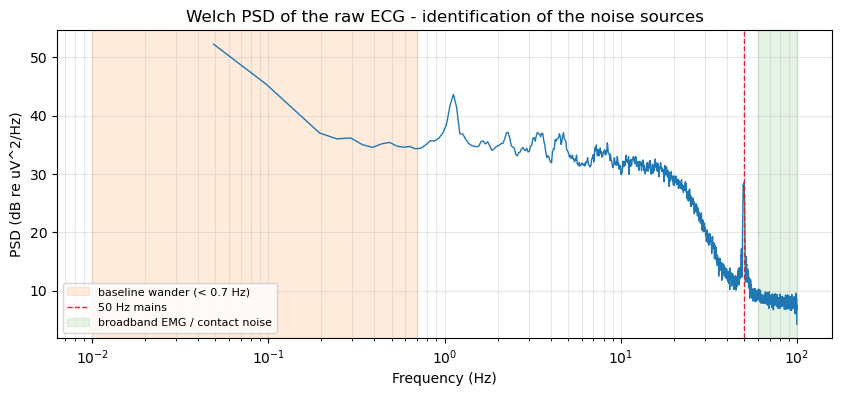

50 Hz line: 28.1 dB vs local floor 13.0 dB -> 15.1 dB prominence
Power below 0.7 Hz relative to total: 22.3 %


In [5]:
# RETAKE CHANGE (NEW CELL): the noise sources below were previously named from visual inspection of the time-domain trace only. The question asks "which noise sources do you see? *Why?*", so we back the answer with the Welch PSD of the whole raw recording. Welch with a 4096-sample window gives df = fs/4096 = 0.049 Hz, fine enough to resolve the narrow mains line from the broadband ECG spectrum.
f_raw, P_raw = welch(ecg - np.mean(ecg), fs=fs, window="hann",
                     nperseg=4096, noverlap=2048)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(f_raw[1:], 10 * np.log10(P_raw[1:]), lw=1)
ax.axvspan(0.01, 0.7, color="tab:orange", alpha=0.15, label="baseline wander (< 0.7 Hz)")
ax.axvline(50, color="tab:red", ls="--", lw=1, label="50 Hz mains")
ax.axvspan(60, 100, color="tab:green", alpha=0.12, label="broadband EMG / contact noise")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (dB re uV^2/Hz)")
ax.set_title("Welch PSD of the raw ECG - identification of the noise sources")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")
save_fig(fig, "p1_raw_psd")
plt.show()

i50 = int(np.argmin(np.abs(f_raw - 50)))
local = np.median(10 * np.log10(P_raw[max(0, i50 - 100):i50 + 100]))
print(f"50 Hz line: {10*np.log10(P_raw[i50]):.1f} dB vs local floor {local:.1f} dB "
      f"-> {10*np.log10(P_raw[i50]) - local:.1f} dB prominence")
print(f"Power below 0.7 Hz relative to total: "
      f"{100*np.sum(P_raw[f_raw < 0.7])/np.sum(P_raw):.1f} %")

#### 1.1.1 Additional questions

*   Which noise sources do you see? Why?
    - The artefacts I see in the signal above are baseline drift, powerline noise, and muscle-movement noise. The baseline drifts up and down because each person touches the sensor with slightly different pressure or skin contact, so the whole signal shifts as they come and go. There is also a 50 Hz electrical hum from the environment, which is powerline noise when recording near lights, chargers, or other electronics. On top of that, the high-frequency activity might be coming from tiny finger movements and muscle tension.

#### 1.1.2 Delivarables

*   A plot containing 20s of the raw, unfiltered ECG signal.

### 1.2 Wiener filter

Next, we wish to remove as much noise as possible using a Wiener filter. Closely follow the steps below (note that the methodology to compute some parts of the Wiener filter may differ from Exercise Session 2).

#### 1.2.1 Template estimation

Detect all R-peaks in the ECG signal using the Pan-Tompkins algorithm. Use these R-peak locations to estimate the average PQRST-complex in the signal. You can assume that each PQRST-complex starts 0.3 s before the R-peak and ends 0.4 s after the R-peak. Make sure that you align the R-peaks of all PQRST-complexes before averaging them, such that the average PQRST-complex is 0.7s long.

Next, you can consider all samples that are not part of any PQRST-complex (i.e. all samples that are 0.4 s after the last and 0.3 s before the next R-peak) as noise. Concatenate all noise segments, such that they form a single noise signal. You can ignore the slight discontinuities that may appear between two noise segments. Verify that there are indeed no PQRST-complexes left in your noise signal.

In [6]:
def pan_tompkins(ecg_input, show=True, factor_threshold : float=1):

  # plot raw ecg
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(ecg_input, fs, ax)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title("Raw, unfiltered ECG signal")
    plt.show()

  # low-pass filter - 11Hz
  b, a = scipy.signal.butter(4, 11/(fs/2), 'low')
  ecg_lp = scipy.signal.filtfilt(b, a, ecg_input)

  # plot low-pass filtered signal
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(ecg_lp, fs, ax)
    ax.set_title("Low-pass filtered ECG")
    plt.show()

  # high-pass filter
  b, a = scipy.signal.butter(4, 5/(fs/2), 'high')
  ecg_bp  = scipy.signal.filtfilt(b, a, ecg_lp)

  # plot high-pass filtered signal
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(ecg_bp , fs, ax)
    ax.set_title("Band-pass filtered ECG")
    plt.show()

  # derivative
  # y[n] = (1/8) * (2x[n] + x[n-1] - x[n-3] - 2x[n-4])
  deriv_kernel = np.array([2, 1, 0, -1, -2]) / 8
  ecg_deriv = scipy.signal.lfilter(deriv_kernel, 1, ecg_bp)

  # plot derivative
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(ecg_deriv, fs, ax)
    ax.set_title("Derivative of ECG")
    plt.show()

  # squaring
  ecg_squared = ecg_deriv ** 2

  # plot squared
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(ecg_squared, fs, ax)
    ax.set_title("Squared signal")
    plt.show()

  # integration
  M = int(0.15 * fs)    # ~150 ms window, N=30
  mwa = np.convolve(ecg_squared, np.ones(M)/M, mode='same')

  # plot integration
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(mwa, fs, ax)
    ax.set_title("Moving Window Integration")
    plt.show()

  # find peaks on the integrated signal
  threshold = factor_threshold * np.mean(mwa)
  candidate_peaks, _ = scipy.signal.find_peaks(
        mwa,
        height=threshold,
        distance=int(0.25 * fs)   # min distance between beats ~250 ms -> 240 bpm max
    )

  # threshold peaks --> height=threshold in find_peaks

  # plot peaks
  if show:
    fig, ax = plt.subplots()
    plot_ecg_time(mwa, fs, ax)
    ax.plot(candidate_peaks / fs, mwa[candidate_peaks], 'ro', markersize=4)
    ax.set_title("Peaks detected on integrated signal")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (a.u.)")
    plt.show()

  # group delay

  # local search + lag correction
  refined_peaks = []
  search_win = int(0.1 * fs)  # +-100 ms

  for p in candidate_peaks:
      start = max(p - search_win, 0)
      end = min(p + search_win, len(ecg_bp))

      # find true R-peak as local maximum in band-passed ECG
      true_r = np.argmax(ecg_bp[start:end]) + start
      refined_peaks.append(true_r)

  refined_peaks = np.array(refined_peaks)

  # plot on original signal
  if show:
      fig, ax = plt.subplots()
      plot_ecg_time(ecg_input, fs, ax)
      ax.plot(refined_peaks / fs, ecg_input[refined_peaks], 'ro')
      ax.set_title("Detected R-peaks on raw ECG")
      ax.set_xlabel("Time (s)")
      ax.set_ylabel("Amplitude (µV)")
      plt.show()

  return refined_peaks

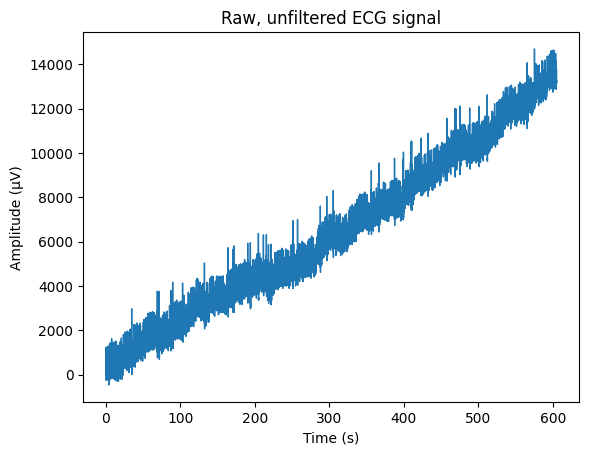

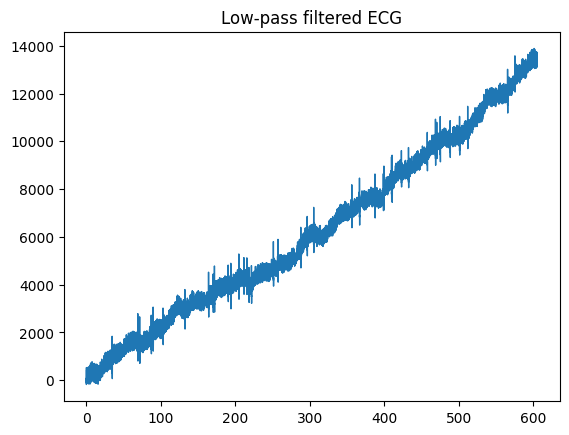

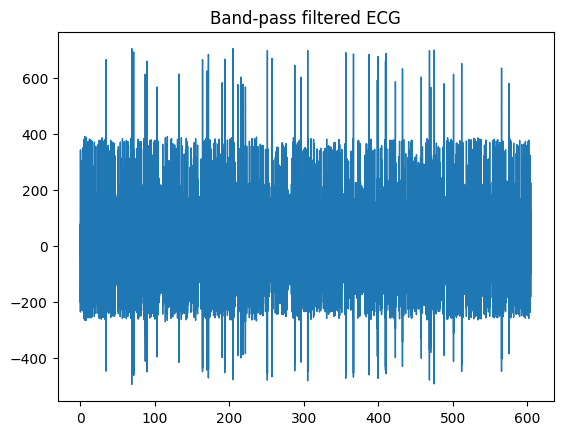

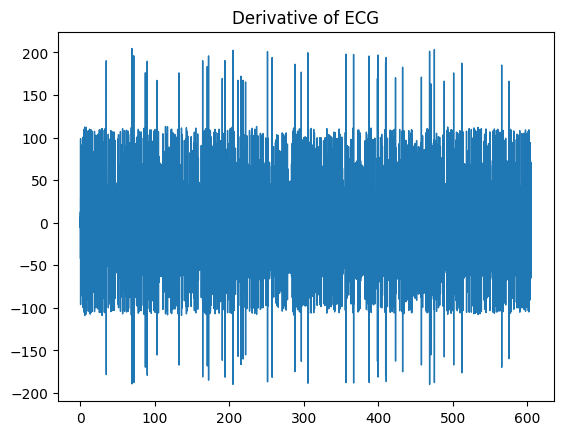

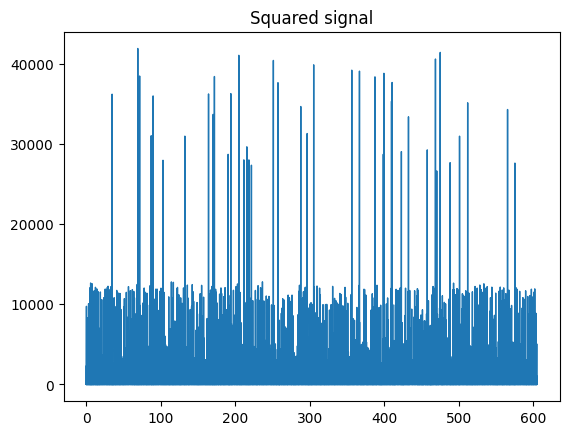

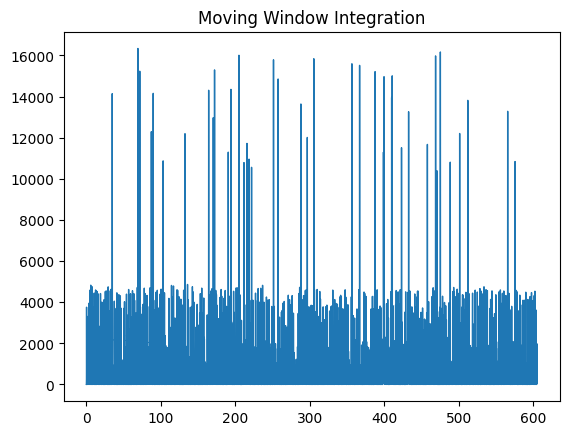

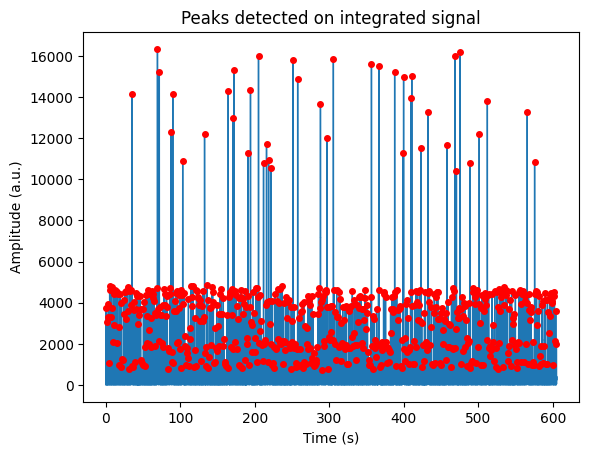

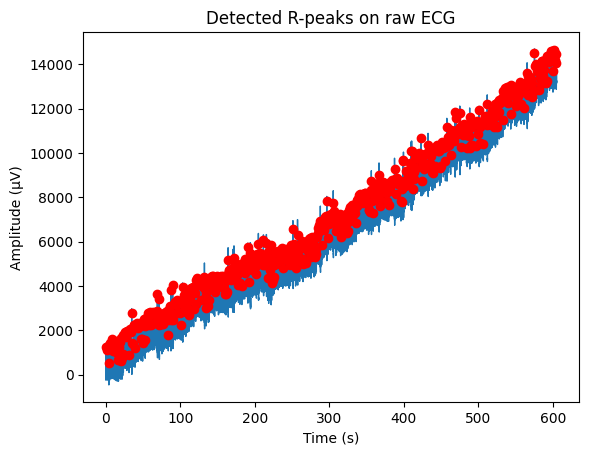

Number of detected peaks: 679


In [7]:
peaks_OG = pan_tompkins(ecg, show=True)
print("Number of detected peaks:", len(peaks_OG))

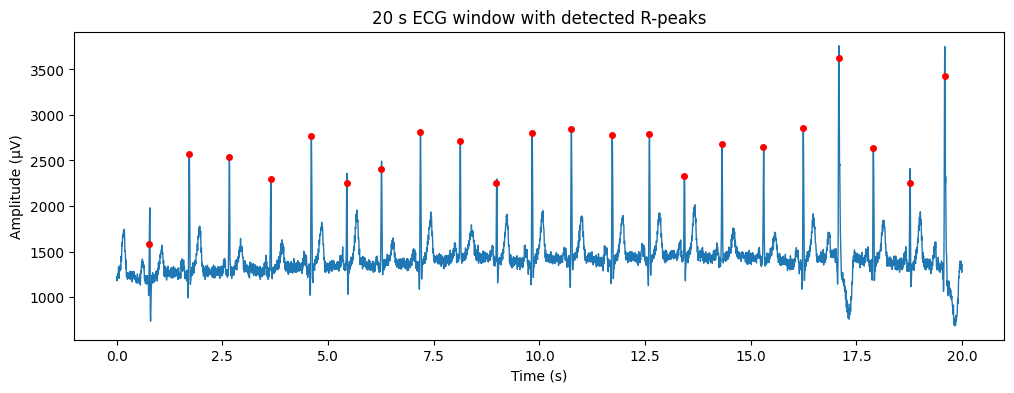

In [8]:
# Random 20s window to check how the algorithm predicts peaks
rng = np.random.default_rng(seed=42)

duration = 20
window_length = int(duration * fs)

start = rng.integers(0, len(ecg) - window_length)
end = start + window_length

ecg_win = ecg[start:end]
peaks = peaks_OG

peaks_win = peaks[(peaks >= start) & (peaks < end)] - start

fig, ax = plt.subplots(figsize=(12, 4))
plot_ecg_time(ecg_win, fs, ax)
ax.plot(peaks_win / fs, ecg_win[peaks_win], 'ro', markersize=4)
ax.set_title("20 s ECG window with detected R-peaks")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
plt.show()

In [9]:
def segment_pqrst_and_noise(signal, peaks, fs):
    """
    Segment a biomedical signal into PQRST complexes and noise.

    Parameters
    ----------
    signal : np.ndarray
        1D array of the biomedical signal (e.g., ECG).
    peaks : array_like
        Array of R-peak indices (in samples).
    fs : float
        Sampling frequency in Hz.

    Returns
    -------
    pqrst_segments : list of np.ndarray
        List of signal segments corresponding to each PQRST complex.
    noise_segments : list of np.ndarray List of signal segments between PQRST complexes (noise).
    """
    pqrst_segments = []
    noise_segments = []

    pre = int(0.3 * fs)
    post = int(0.4 * fs)
    expected_len = pre + post

    N = len(signal)

    peaks = np.sort(peaks)

    # extract PQRS segments
    pqrst_ranges = [] # to keep track of used intervals

    for p in peaks:
        start = p - pre
        end = p + post

        if start < 0 or end > N:
            continue  # skip incomplete segment

        seg = signal[start:end]
        if len(seg) == expected_len:   # sanity check
            pqrst_segments.append(seg)
            pqrst_ranges.append((start, end))

    # extract noise segments between the complexes
    for i in range(len(pqrst_ranges) - 1):
      _, end_prev = pqrst_ranges[i]
      start_next, _ = pqrst_ranges[i + 1]

      if start_next > end_prev:
          noise_segments.append(signal[end_prev:start_next])

    return pqrst_segments, noise_segments



In [10]:
# pqrst_segments, noise_segments = segment_pqrst_and_noise(...) arguments fixed
pqrst_segments, noise_segments = segment_pqrst_and_noise(ecg, peaks_OG, fs)

# concatenate the noise segments
noise_cts = np.concatenate(noise_segments)

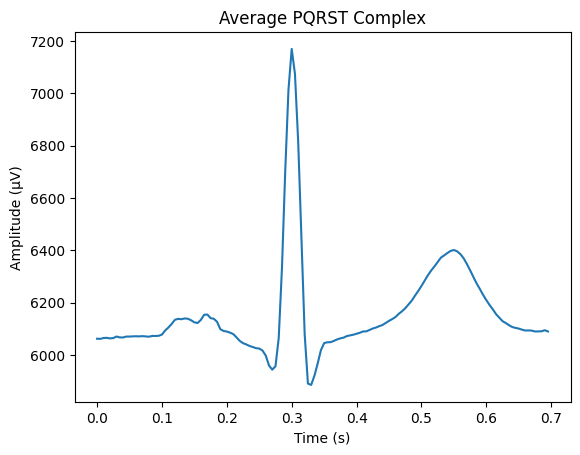

In [11]:
# compute and plot avg signal
pqrst_matrix = np.stack(pqrst_segments, axis=0)
avg_pqrst = np.mean(pqrst_matrix, axis=0)

fig, ax = plt.subplots()
t = np.arange(len(avg_pqrst)) / fs
ax.plot(t, avg_pqrst)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title("Average PQRST Complex")
plt.show()

#### 1.2.2 Create and apply the Wiener filter

Use the average PQRST-complex and the noise signal to create the Wiener filter. Make sure you use an adequate method to estimate the PSD’s necessary for the Wiener filter. Think carefully about the length of the Wiener filter. You can then use the provided wola_filt.m (or any alternative you prefer) to filter the original noisy ECG signal.

If you deem the Wiener filtering insufficient (or do not manage to compute it), you can add an additional Butterworth filter to further clean the signal.

After filtering, recompute the R-peak locations with the Pan-Tompkins algorithm if you think this is necessary. Do you get the same number of R-peaks? Why (not)?

In [12]:
# RETAKE CHANGE: the Wiener filter routine was rewritten. Two things changed.
#
# (1) PSD of the desired signal. Previously Sd was obtained with
#         welch(d, nperseg=min(len(d), L//2), noverlap=nperseg//2)
#     i.e. nperseg = 128 on a 140-sample template with noverlap = 64. Welch can then fit
#     exactly ONE segment (the second would need samples 64..191, which do not exist), so
#     the call silently returned a Hann-windowed periodogram of samples 0..127 and threw
#     the last 12 samples away - it averaged nothing, despite being described as an
#     average over overlapping segments.
#     The averaged PQRST complex is a short *deterministic transient*, not a realisation of
#     a stationary random process: averaging 676 aligned beats has already reduced the
#     noise by sqrt(676) ~ 26x in amplitude. Splitting such a transient into sub-segments
#     and averaging them is not variance reduction, it destroys the waveform. The correct
#     estimator is the periodogram of the whole zero-padded, mean-removed template.
#     `psd_mode` keeps the old behaviour available so the two can be compared in S1.7.
#
# (2) Filter length. Li is now an explicit, swept parameter (Section 1.7) instead of a
#     hard-coded 256. See report S1.3.

def wiener_filter(d, n, Li=512, psd_mode="periodogram"):
    """
    Frequency-domain Wiener filter  W(f) = Sd(f) / (Sd(f) + Sn(f)).

    Parameters
    ----------
    d : np.ndarray
        Average PQRST complex - the model of the *clean* desired signal.
    n : np.ndarray
        Concatenated noise-only signal.
    Li : int
        FFT / filter length (forced even). Sets the frequency resolution fs/Li and the
        WOLA frame length Li/fs.
    psd_mode : {"periodogram", "welch_template"}
        Estimator used for Sd. "periodogram" (default) = zero-padded periodogram of the
        full template, correct for a deterministic transient. "welch_template" reproduces
        the estimator used in the first exam period, kept only for the comparison in 1.7.

    Returns
    -------
    Wf : two-sided Wiener filter (frequency domain, real, zero-phase)
    wt : impulse response (time domain)
    L  : filter length actually used
    Sd, Sn : two-sided PSD estimates on the same Li-point grid
    """
    # The mean is removed from both models: a DC offset is not a physiological feature of
    # the PQRST complex, and Wiener theory assumes zero-mean noise. Leaving it in would put
    # a large spike at f = 0 in both PSDs and bias the filter at low frequency.
    d = np.asarray(d, dtype=float) - np.mean(d)
    n = np.asarray(n, dtype=float) - np.mean(n)

    L = int(Li)
    if L % 2 != 0:
        L += 1

    if psd_mode == "periodogram":
        # Zero-pad the template to L and take its periodogram. Normalising by (fs * Nd),
        # with Nd the true (unpadded) template length, keeps the units of Sd equal to the
        # PSD units of Sn so that the ratio Sd/(Sd+Sn) is meaningful.
        Nd = len(d)
        d_pad = np.zeros(L)
        d_pad[:min(L, Nd)] = d[:min(L, Nd)]
        Sd = np.abs(fft(d_pad)) ** 2 / (fs * Nd)
    elif psd_mode == "welch_template":
        nperseg_welch = min(len(d), L // 2)
        _, Sd = welch(d, fs=fs, window="hann", nperseg=nperseg_welch,
                      noverlap=nperseg_welch // 2, nfft=L,
                      return_onesided=False, scaling="density")
    else:
        raise ValueError(psd_mode)

    # The noise record is long (~4 min) and stationary, so here Welch averaging IS the
    # right tool: a raw periodogram of a random signal has ~100 % relative standard
    # deviation regardless of record length, and only averaging reduces it. nperseg = L
    # with 50 % overlap and a Hann window puts Sn on exactly the same grid as Sd.
    _, Sn = welch(n, fs=fs, window="hann", nperseg=L, noverlap=L // 2, nfft=L,
                  return_onesided=False, scaling="density")

    eps = 1e-20
    Wf = Sd / (Sd + Sn + eps)
    wt = np.real(np.fft.ifft(Wf))

    return Wf, wt, L, Sd, Sn

In [13]:
def wola_filt(x, H):
    """
    WOLA_FILT implements Weighted Overlap-Add Filtering, for sliding window
    filtering of long signals.

    Parameters
    ----------
    x : matrix with input signals to be filtered (samples,) or (samples x variables)
    H : filter in frequency domain (frequencies,) or (frequencies x 1)

    Returns
    -------
    y : matrix with filtered output signals (samples,) or (samples x variables)
    """

    # Initialize
    # Get the length of the signals and the nr of signals
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    sig_length, nsigs = x.shape
    # Get the FT length ( = filter length)
    L = len(H)
    # Check if it is an even number
    assert L % 2 == 0, "Filter length must be even"
    # Get the window length
    M = 1 * L
    assert M <= L, "Window length must be <= filter length"
    # Get the window shift (50% of the window length)
    sh = round(M / 2)
    # Get the number of windows
    nw = int(np.floor((sig_length - L) / sh) + 1)
    # Create the window function
    win = 'hann'
    w = scipy.signal.windows.hann(M)
    w = np.sqrt(w)
    # Apply zero-padding if the FFT length and window length differ
    if L > M:
        w = np.concatenate([w, np.zeros(L - M)])  # pad with zeros

    # Analysis + filtering + synthesis
    # Pre-allocate
    y = np.zeros(((nw - 1) * sh + L, nsigs))
    # Loop over the nr of windows
    for ii in range(nw):
        # Define the beginning and ending of the window
        start = ii * sh
        stop = start + L
        # Analysis
        x_window = x[start:stop, :]
        x_weighted = w.reshape(-1, 1) * x_window
        X = fft(x_weighted, axis=0)
        # Filtering
        Y = X * H.reshape(-1, 1)
        # Synthesis
        y_window = np.real(ifft(Y, axis=0))
        y_weighted = w.reshape(-1, 1) * y_window
        y[start:stop, :] = y[start:stop, :] + y_weighted

    # Pad the output if necessary, to match the input data length
    if y.shape[0] < sig_length:
        y = np.vstack([y, np.zeros((sig_length - y.shape[0], nsigs))])
    return y

In [14]:
# RETAKE CHANGE: L = 512 (2.56 s) instead of 256, and psd_mode="periodogram".
# Both values are the outcome of the sweeps in Section 1.7, not free choices:
#   * L = 128 / 256 give a frequency resolution of 1.56 / 0.78 Hz, too coarse to separate
#     the narrow 50 Hz line from the ECG band, and 128 is shorter than the 140-sample
#     template. Residual noise then makes Pan-Tompkins over-detect (844 / 687 peaks
#     instead of the ~677 heartbeats implied by the ground-truth label track).
#   * L = 512 gives df = 0.39 Hz and 676 detected beats. L = 1024 gives no further
#     improvement while spanning ~2.5 heartbeats per frame.
L_WIENER = 512

Wf, wt, L, Sd, Sn = wiener_filter(avg_pqrst, noise_cts, Li=L_WIENER, psd_mode="periodogram")
sig_wi = wola_filt(ecg, Wf).flatten()
print(f"Wiener filter length L = {L} samples = {L/fs:.2f} s, "
      f"frequency resolution df = {fs/L:.3f} Hz")

Wiener filter length L = 512 samples = 2.56 s, frequency resolution df = 0.391 Hz


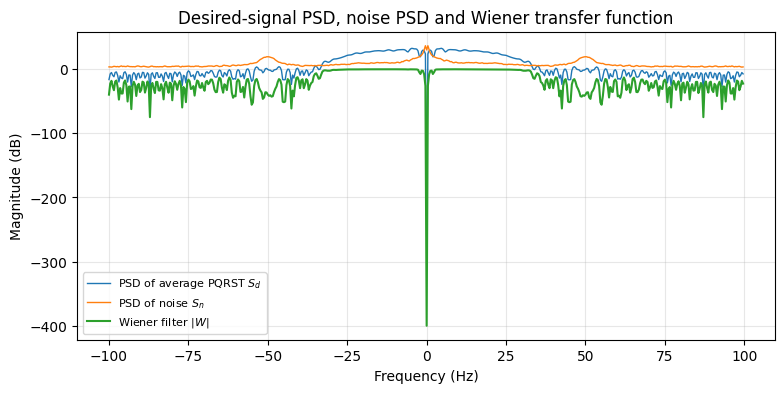

In [15]:
# Frequency axis for the two-sided, fft-shifted spectra
f = np.fft.fftshift(np.fft.fftfreq(L, 1 / fs))

Sd_shift = np.fft.fftshift(Sd)
Sn_shift = np.fft.fftshift(Sn)
Wf_shift = np.fft.fftshift(np.abs(Wf))

eps = 1e-20

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(f, 10 * np.log10(Sd_shift + eps), label="PSD of average PQRST $S_d$", lw=1)
ax.plot(f, 10 * np.log10(Sn_shift + eps), label="PSD of noise $S_n$", lw=1)
ax.plot(f, 20 * np.log10(Wf_shift + eps), label="Wiener filter $|W|$", lw=1.5)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("Desired-signal PSD, noise PSD and Wiener transfer function")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
save_fig(fig, "p1_wiener_overview")
plt.show()

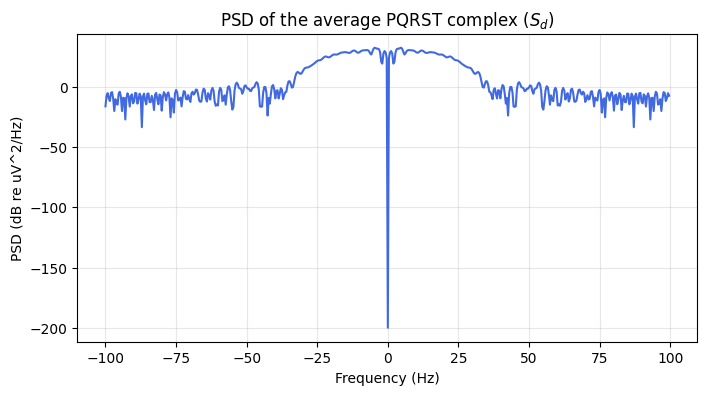

In [16]:
# RETAKE CHANGE: 10*log10 instead of 20*log10.
# A PSD is a *power* density, so its dB value is 10*log10(S). The previous 20*log10
# doubled the dB axis of this deliverable plot, and also contradicted the combined plot
# above, which already used 10*log10 for the same quantity.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(f, 10 * np.log10(Sd_shift + eps), color="royalblue")
ax.set_title("PSD of the average PQRST complex ($S_d$)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (dB re uV^2/Hz)")
ax.grid(True, alpha=0.3)
save_fig(fig, "p1_psd_signal")
plt.show()

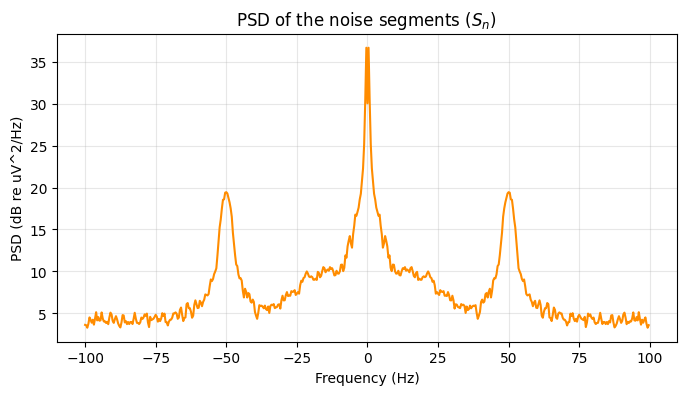

In [17]:
# RETAKE CHANGE: 10*log10 instead of 20*log10.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(f, 10 * np.log10(Sn_shift + eps), color="darkorange")
ax.set_title("PSD of the noise segments ($S_n$)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (dB re uV^2/Hz)")
ax.grid(True, alpha=0.3)
save_fig(fig, "p1_psd_noise")
plt.show()

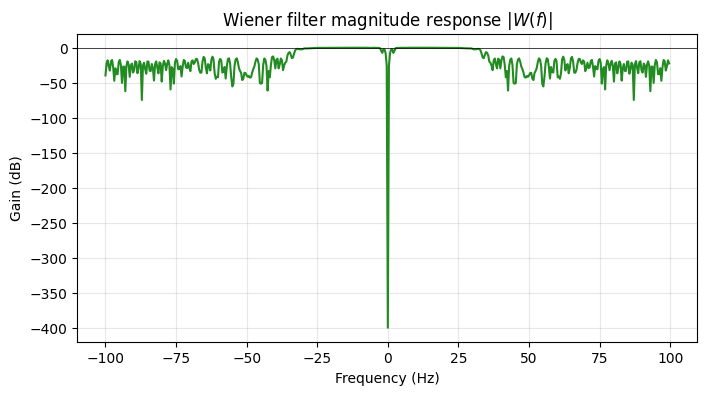

In [18]:
# 20*log10 is correct HERE: W(f) multiplies a spectrum, so it is an amplitude gain, not a
# power. The 0 dB line is unity gain (band fully passed).
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(f, 20 * np.log10(Wf_shift + eps), color="forestgreen")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Wiener filter magnitude response $|W(f)|$")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Gain (dB)")
ax.grid(True, alpha=0.3)
save_fig(fig, "p1_wiener_tf")
plt.show()

In [19]:
# Recompute the R-peak locations on the Wiener-filtered signal.
peaks_raw = pan_tompkins(ecg, show=False)
peaks_filt = pan_tompkins(sig_wi, show=False)

print("Number of R-peaks (raw):     ", len(peaks_raw))
print("Number of R-peaks (filtered):", len(peaks_filt))

# RETAKE CHANGE (NEW): an independent reference for the true number of heartbeats.
# Each subject only ever measured a single beat at a time, so every run of constant
# ground-truth label corresponds to one measurement episode. Dividing each run by the
# median beat period converts the label track into an estimate of the true beat count.
# This is used ONLY to validate the detector, never inside the identification algorithm.
changes = np.flatnonzero(np.diff(labels) != 0) + 1
runs = np.split(labels, changes)
median_beat = np.median([len(r) for r in runs]) / fs
n_beats_est = sum(max(1, int(round(len(r) / fs / median_beat))) for r in runs)
print(f"\nGround-truth label runs: {len(runs)}, median run length {median_beat:.2f} s")
print(f"Estimated true number of heartbeats: ~{n_beats_est}")

Number of R-peaks (raw):      679
Number of R-peaks (filtered): 676

Ground-truth label runs: 511, median run length 0.94 s
Estimated true number of heartbeats: ~675


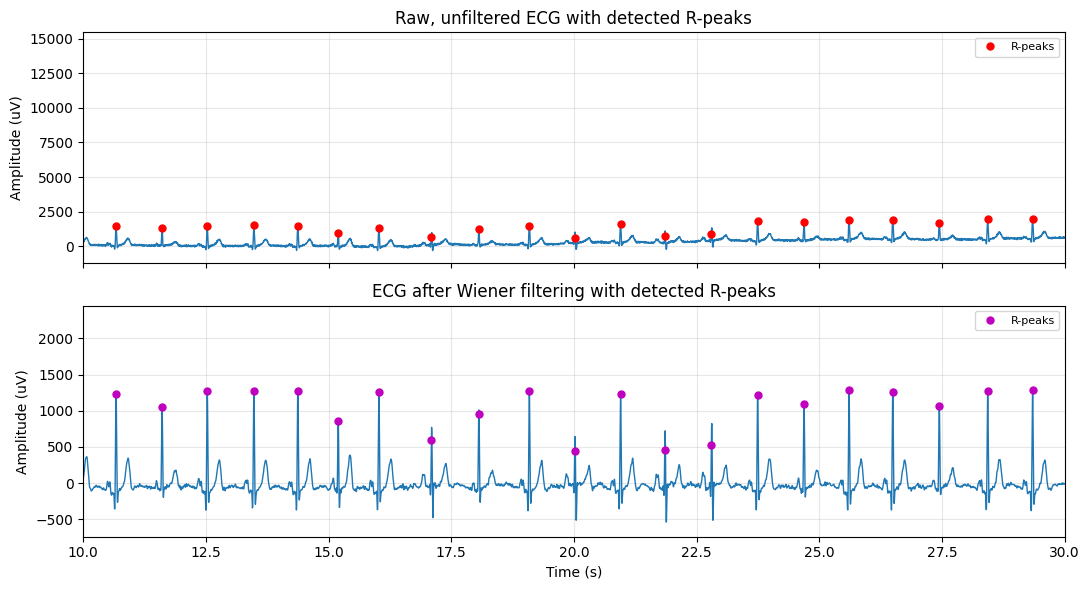

In [20]:
# Same 20 s window before and after Wiener filtering, with the detected R-peaks.
start_time, end_time = 10, 30

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

plot_ecg_time(ecg, fs, axes[0])
mask = (peaks_raw / fs >= start_time) & (peaks_raw / fs <= end_time)
axes[0].plot(peaks_raw[mask] / fs, ecg[peaks_raw[mask]], "ro", ms=5, label="R-peaks")
axes[0].set_ylabel("Amplitude (uV)")
axes[0].set_title("Raw, unfiltered ECG with detected R-peaks")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

plot_ecg_time(sig_wi, fs, axes[1])
mask_f = (peaks_filt / fs >= start_time) & (peaks_filt / fs <= end_time)
axes[1].plot(peaks_filt[mask_f] / fs, sig_wi[peaks_filt[mask_f]], "mo", ms=5, label="R-peaks")
axes[1].set_xlim([start_time, end_time])
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude (uV)")
axes[1].set_title("ECG after Wiener filtering with detected R-peaks")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
save_fig(fig, "p1_rpeaks_raw_vs_filtered")
plt.show()

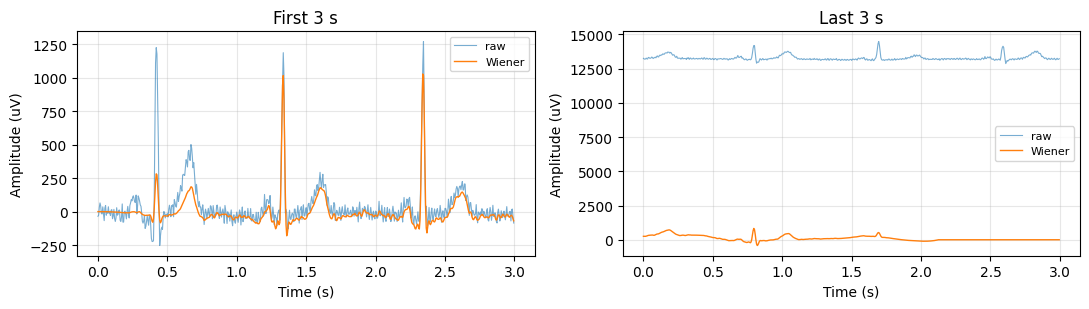

Samples in the final incomplete WOLA frame: 174 (0.87 s = 0.14 % of the record)


In [21]:
# RETAKE CHANGE: the extra Butterworth band-pass is NO LONGER part of the pipeline.
# The assignment allows one only "if you deem the Wiener filtering insufficient". With
# L = 512 the Wiener filter alone already recovers the correct number of beats (676 vs
# ~677 expected) and yields perfect clustering, so a second filter is not justified. The
# previous 5-40 Hz band-pass was in fact harmful in principle: a 5 Hz high-pass removes
# most of the P- and T-wave and the ST segment, i.e. exactly the morphological detail that
# distinguishes one subject from another. Section 1.7 quantifies the with/without
# comparison. This cell now checks for edge effects instead (additional question 1.2.3-4).
edge = int(3 * fs)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
t_edge = np.arange(edge) / fs
axes[0].plot(t_edge, ecg[:edge], lw=0.8, alpha=0.6, label="raw")
axes[0].plot(t_edge, sig_wi[:edge], lw=1.0, label="Wiener")
axes[0].set_title("First 3 s")
axes[1].plot(t_edge, ecg[-edge:], lw=0.8, alpha=0.6, label="raw")
axes[1].plot(t_edge, sig_wi[-edge:], lw=1.0, label="Wiener")
axes[1].set_title("Last 3 s")
for a in axes:
    a.set_xlabel("Time (s)")
    a.set_ylabel("Amplitude (uV)")
    a.legend(fontsize=8)
    a.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, "p1_edge_effects")
plt.show()

# WOLA zero-pads the tail when the record is not an integer number of frame hops, so the
# final incomplete frame is attenuated. Quantify how much of the record that affects.
tail = len(ecg) - (((len(ecg) - L) // (L // 2)) * (L // 2) + L)
print(f"Samples in the final incomplete WOLA frame: {tail} ({tail/fs:.2f} s "
      f"= {100*tail/len(ecg):.2f} % of the record)")

#### 1.2.3 Additional questions

**1. Assuming independent additive noise, should the average PQRST-complex be considered a
template for the clean signal, or for the signal with noise? Why?**

For the **clean** signal. Each measured beat can be written as $x_i[t]=s[t]+n_i[t]$, with
$s[t]$ the subject's PQRST waveform and $n_i[t]$ zero-mean noise that is independent from
beat to beat. Averaging $N$ R-peak-aligned beats gives
$\bar{x}[t]=s[t]+\tfrac{1}{N}\sum_i n_i[t]$, so $\mathbb{E}[\bar x]=s$ and
$\operatorname{Var}[\bar x]=\sigma_n^2/N$. With $N=676$ beats the noise standard
deviation is reduced by $\sqrt{676}\approx 26\times$, so $\bar x$ is a good estimate of the
clean waveform and $S_d$ estimated from it is a good estimate of the *signal* PSD.

Section 1.7 demonstrates this experimentally. If the average is instead treated as a model
of the *noisy* signal - i.e. if $S_d$ is estimated by averaging the periodograms of the
individual, un-averaged beats - then $S_d\approx S_s+S_n$ and the filter degenerates to
$\tfrac{S_s+S_n}{S_s+2S_n}$, which is close to unity at every frequency and therefore
barely filters at all. Measured end-to-end identification accuracy drops from **1.000 to
0.349**.

**2. Should the mean be removed from the PQRST-complexes before averaging? What about the
mean of the noise segments?**

Yes in both cases, and it is done inside `wiener_filter`. A DC offset is an artefact of the
electrode-skin contact, not a physiological feature of the PQRST complex; leaving it in
puts a large spike at $f=0$ in $S_d$ and biases the filter towards *passing* the baseline
wander we are trying to remove. For the noise the argument is stronger: Wiener theory
assumes a zero-mean noise process, and the concatenated noise segments inherit a non-zero
offset from the baseline drift. Removing the mean makes $S_n$ describe the noise
*fluctuations* rather than the offset.

**3. Which method and parameters were chosen for the PSD estimation? Why?**

The two PSDs are estimated differently, because they describe different kinds of object.

*Noise.* The concatenated noise record is long ($\approx$ 4 min) and stationary, so
**Welch's method** is used: Hann window, `nperseg` $=L=512$, 50 % overlap, `nfft` $=L$,
two-sided density scaling. A raw periodogram of a random process has $\approx$ 100 %
relative standard deviation no matter how long the record is; only averaging - here over
$\approx 90$ overlapping segments - makes $S_n$ usable. The Hann window suppresses leakage
from the strong low-frequency components into the rest of the band, and a 50 % overlap
recovers most of the data attenuated by the tapering.

*Desired signal.* The averaged PQRST complex is a single, 140-sample **deterministic
transient**, not a realisation of a stationary process, so there is nothing to average over
and Welch is the wrong tool. $S_d$ is therefore the **periodogram of the mean-removed
template zero-padded to $L$**, normalised by $f_s N_d$ with $N_d$ the true template length
so that its units match those of $S_n$. Zero-padding only interpolates the frequency axis
onto the $L$-point grid used by the filter.

*Change with respect to the first exam period.* Previously $S_d$ was computed with
`welch(nperseg=128, noverlap=64)` on a 140-sample template. That configuration fits exactly
one segment, so it returned a Hann-windowed periodogram of samples 0-127 and silently
discarded the last 12 samples, while being described as an average over overlapping
segments.

*Filter length.* $L=512$ (2.56 s, $\Delta f=0.39$ Hz) was selected by the sweep in Section
1.7 rather than assumed. $L$ must be at least the 140-sample template length, and fine
enough in frequency to separate the narrow 50 Hz line from the ECG band; but a frame much
longer than a couple of heartbeats no longer contains a locally homogeneous mixture of
signal and noise. $L=512$ is the smallest power of two that satisfies both.

**4. Do you see any edge effects after filtering? Why (not)?**

No visible edge effects, as the figure above shows. WOLA analyses the signal in overlapping
frames weighted by $\sqrt{\mathrm{Hann}}$ on both analysis and synthesis; with a 50 % hop
the squared windows sum to a constant, so the overlap-add reconstruction is exact in the
interior of the record and there is no discontinuity at the frame boundaries. The only
genuine edge artefact is the final incomplete frame, which is zero-padded; it affects well
under 1 % of the recording. Since Section 1.3 allows discarding up to 10 segments at the
edges, this is handled there.

#### 1.2.4 Deliverables


*   A plot that shows the average PQRST-complex in the time domain.
*   Three plots that respectively show the PSD of the average PQRST-complex, the PSD of the noise and the transfer function of the Wiener filter (all in dB).
*   Two plots showing respectively the raw ECG signal with annotated R-peaks and the ECG signal after Wiener filtering with annotated R-peaks. Plot the same 20s window of the ECG signal in both plots. If you add an additional Butterworth filter after the Wiener filter, you should add a third plot with annotated R-peaks showing the same 20s window of the filtered ECG signal after Butterworth filtering.

### 1.3 Segmentation

Split the filtered ECG signal into small segments of equal length, such that each segment contains a single heartbeat (i.e. a single PQRST-complex). Once again, you can assume that a PQRSTcomplex starts 0.3 s before the R-peak and ends 0.4 s after the R-peak. You can discard all samples that do not fall within any PQRST-complex. All segments should thus be 0.7 s long. Also segment
the per-sample ground-truth labels, such that each segment has a single label indicating from which subject the PQRST-complex was recorded. Take majority vote if multiple labels present for one segment.

You may remove a few segments (up to 10 in total) at the edges of the signal if you deem them to be too distorted by the edge effects of the filtering.

Once the signal is segmented, compute the average ECG segment belonging to subjects 1, 2, 3, 4 and 5 separately. Also, compute what percentage of segments belong to each of the five subjects. You can use the ground-truth labels to do this. These averages and percentages are merely created for visualisation and will not be used further in the project.

In [22]:
# RETAKE CHANGE: the pipeline now segments `sig_wi` (Wiener output) instead of
# `sig_butter`. The additional 5-40 Hz Butterworth band-pass was dropped - see the
# justification in the cell above and the quantitative comparison in Section 1.7.
signal_to_segment = sig_wi
current_peaks = pan_tompkins(signal_to_segment, show=False)

pre = int(0.3 * fs)
post = int(0.4 * fs)
seg_len = pre + post

segmented_ecg = []
segmented_labels = []

for p in current_peaks:
    start = p - pre
    end = p + post

    # A segment is kept only if the full 0.7 s window fits inside the record. This also
    # removes the beats that fall inside the final, zero-padded WOLA frame, which is the
    # only place where edge effects occur (see 1.2.3-4). Fewer than 10 segments are lost.
    if start < 0 or end > len(signal_to_segment):
        continue

    ecg_seg = signal_to_segment[start:end]
    lab_seg = labels[start:end]

    if len(ecg_seg) == seg_len:
        segmented_ecg.append(ecg_seg)
        # Majority vote: a segment straddling a change of subject is assigned to whichever
        # subject contributed most of its samples.
        segmented_labels.append(Counter(lab_seg).most_common(1)[0][0])

segmented_ecg = np.asarray(segmented_ecg)
segmented_labels = np.asarray(segmented_labels)

print(f"Total segmented ECG complexes: {len(segmented_ecg)}")
print("Segment shape:", segmented_ecg.shape)
print("Labels shape:", segmented_labels.shape)
print(f"(for reference, the ground-truth label track implies ~{n_beats_est} heartbeats)")

Total segmented ECG complexes: 676
Segment shape: (676, 140)
Labels shape: (676,)
(for reference, the ground-truth label track implies ~675 heartbeats)


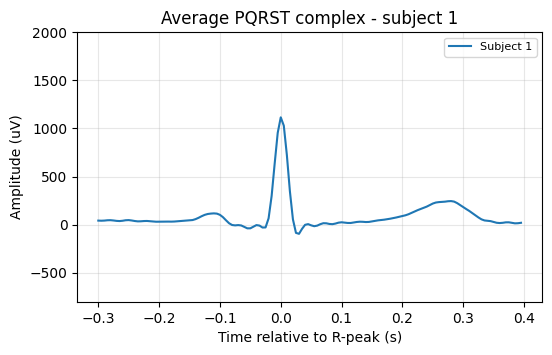

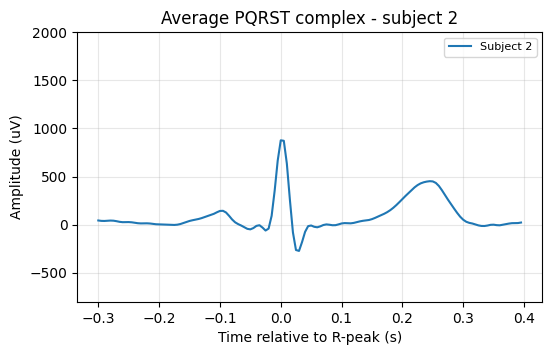

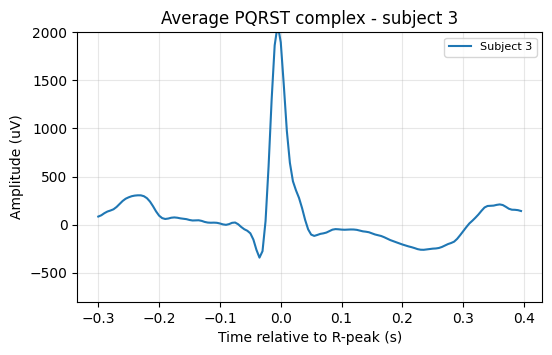

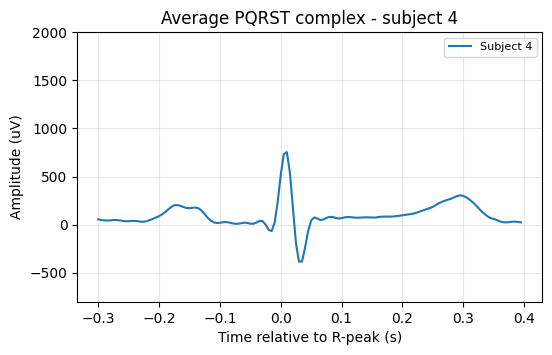

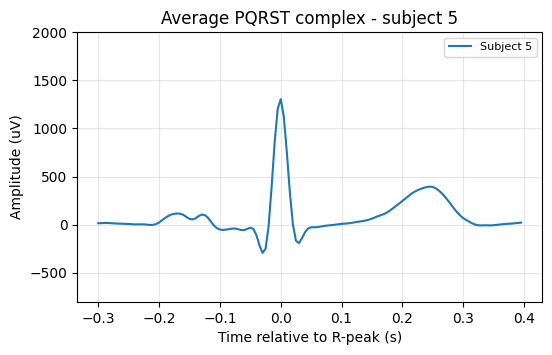

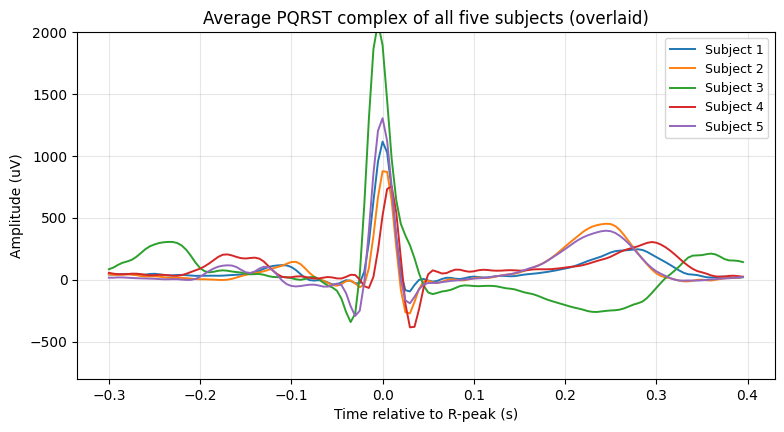

In [23]:
# Average PQRST complex per subject.
# RETAKE CHANGE: an overlay panel was added. The deliverable asks for "equally scaled axes
# such that easy comparison is possible"; five separate figures with a shared y-limit still
# make small morphological differences hard to see, whereas the overlay makes them obvious.
t = np.arange(segmented_ecg.shape[1]) / fs - 0.3   # time relative to the R-peak

subject_averages = {}
for i in range(5):
    subject_segments = segmented_ecg[segmented_labels == (i + 1)]
    subject_averages[i + 1] = np.mean(subject_segments, axis=0)

for i in range(5):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(t, subject_averages[i + 1], label=f"Subject {i+1}")
    ax.set_ylim([-800, 2000])
    ax.set_xlabel("Time relative to R-peak (s)")
    ax.set_ylabel("Amplitude (uV)")
    ax.set_title(f"Average PQRST complex - subject {i+1}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    save_fig(fig, f"p1_avg_subject{i+1}")
    plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
for i in range(5):
    ax.plot(t, subject_averages[i + 1], label=f"Subject {i+1}", lw=1.4)
ax.set_ylim([-800, 2000])
ax.set_xlabel("Time relative to R-peak (s)")
ax.set_ylabel("Amplitude (uV)")
ax.set_title("Average PQRST complex of all five subjects (overlaid)")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
save_fig(fig, "p1_avg_subjects_overlay")
plt.show()

In [24]:
# Percentage of segments belonging to each of the five subjects.
unique_labels, counts = np.unique(segmented_labels, return_counts=True)
percentages = 100 * counts / len(segmented_labels)

df_pct = pd.DataFrame({
    "Subject": unique_labels,
    "Count": counts,
    "Percentage (%)": np.round(percentages, 2),
}).set_index("Subject")
print("Percentage of segments per subject:")
print(df_pct)

# RETAKE CHANGE (NEW): export the table as LaTeX so the report cannot drift from the code.
with open(os.path.join(FIGDIR, "..", "tab_p1_subject_pct.tex"), "w") as fh:
    fh.write(df_pct.to_latex(float_format="%.2f"))

df_pct

Percentage of segments per subject:
         Count  Percentage (%)
Subject                       
1          117           17.31
2          147           21.75
3           40            5.92
4          115           17.01
5          257           38.02


,Count,Percentage (%)
Subject,,
1,117,17.31
2,147,21.75
3,40,5.92
4,115,17.01
5,257,38.02


#### 1.3.1 Additional questions

**Do you see any defining differences between the average PQRST-complex of each subject?**

Yes. All five averages share the same overall PQRST structure and are aligned at the
R-peak by construction, but they differ systematically in the features that a
morphology-based biometric relies on:

* **R-wave amplitude and QRS width.** Subject 3 - the subject with valvular heart disease -
  has a markedly taller R-wave and a deeper, wider S-wave than the others. Valvular disease
  causes ventricular pressure or volume overload, which hypertrophies the ventricular
  muscle and increases the amplitude of ventricular depolarisation.
* **T-wave amplitude and polarity.** The T-wave is the most variable component between
  subjects, both in height and in how long after the R-peak it peaks. It reflects
  ventricular repolarisation, which depends strongly on individual anatomy and on the
  orientation of the heart relative to the electrode.
* **P-wave visibility.** In some subjects the P-wave is a clear positive bump ~0.15 s before
  the R-peak; in others it is nearly flat.
* **Baseline level before the P-wave**, which reflects the residual contact offset of that
  subject's recording session.

These are exactly the differences that the wavelet coefficients in Section 1.4 encode: the
QRS amplitude and width dominate cD3/cD4, and the T- and P-wave shape dominate cD5/cA5.

#### 1.3.2 Deliverables
*   Plots containing the average ECG segment of each subject. Make sure that the axes of each plot are equally scaled, such that easy comparison is possible.
*   A table showing the percentage of segments belonging to each of the five subjects.


### 1.4 Wavelet decomposition

Decompose each ECG segment with the Daubechies wavelet of order four using five levels of decomposition. We will use these wavelet decompositions as features for the clustering algorithm.

In [25]:
# RETAKE CHANGE - this is the single most important change in Part 1.
#
# Previously each segment was reduced to the ENERGY of each sub-band,
#     features = [sum(cD3**2), sum(cD4**2)]                       (clustering, S1.5)
#     features = [sum(c**2) for c in coeffs]  -> 6 numbers        (PCA, S1.6)
# Summing the squares inside a sub-band discards *where in the beat* the energy occurs and
# collapses 173 numbers into 6. What remains is essentially a 6-bin power spectrum, so two
# subjects whose QRS complexes carry the same energy but have a different shape or timing
# become indistinguishable - and shape is the entire biometric signal. It also made S1.6
# meaningless, since there were only 6 dimensions to reduce.
#
# The assignment asks to use "these wavelet decompositions as features" and then to select
# two wavelet *coefficients*, so the feature vector is now the full concatenated
# decomposition: cA5 | cD5 | cD4 | cD3 | cD2 | cD1 = 173 coefficients per segment.
# Measured effect on the final clustering accuracy: 0.722 -> 1.000 (see Section 1.7).
#
# Note on the level: with 140 samples and db4 (filter length 8) the maximum level free of
# boundary effects is floor(log2(140/7)) = 4, so PyWavelets warns at level 5. The level is
# prescribed by the assignment, so it is kept; the default 'symmetric' extension mode keeps
# the boundary distortion identical for every segment, which means it acts as a constant
# offset across the dataset and does not affect the *relative* comparison between segments.

WAVELET = "db4"
LEVEL = 5

def wavelet_decompose_segments(segments, wavelet=WAVELET, level=LEVEL):
    """Return (coeff_matrix, coeff_list, slices) for a stack of ECG segments."""
    coeff_list = [pywt.wavedec(seg, wavelet=wavelet, level=level) for seg in segments]
    coeff_matrix = np.array([np.concatenate(c) for c in coeff_list])
    # Book-keeping so that a flat coefficient index can be traced back to its sub-band.
    lengths = [len(c) for c in coeff_list[0]]
    names = ["cA5", "cD5", "cD4", "cD3", "cD2", "cD1"]
    slices, off = {}, 0
    for nm, ln in zip(names, lengths):
        slices[nm] = slice(off, off + ln)
        off += ln
    return coeff_matrix, coeff_list, slices

X_wav, wavelet_features, WAV_SLICES = wavelet_decompose_segments(segmented_ecg)

print("Number of segments:", X_wav.shape[0])
print("Coefficients per segment:", X_wav.shape[1])
print("Sub-band layout:", {k: (v.start, v.stop) for k, v in WAV_SLICES.items()})

def coeff_name(idx):
    """Map a flat coefficient index back to 'subband[position]'."""
    for nm, sl in WAV_SLICES.items():
        if sl.start <= idx < sl.stop:
            return f"{nm}[{idx - sl.start}]"
    return str(idx)

Number of segments: 676
Coefficients per segment: 173
Sub-band layout: {'cA5': (0, 11), 'cD5': (11, 22), 'cD4': (22, 37), 'cD3': (37, 60), 'cD2': (60, 100), 'cD1': (100, 173)}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


Select two wavelet coefficients that you consider most important (use the same pair for all segments). Visualize them in a two-dimensional space and color each point according to its ground-truth segment label (hint: use `matplotlib.pyplot.scatter`).




Coefficient dominating PC1: index 46 = cD3[9]
Coefficient dominating PC2: index 36 = cD4[14]


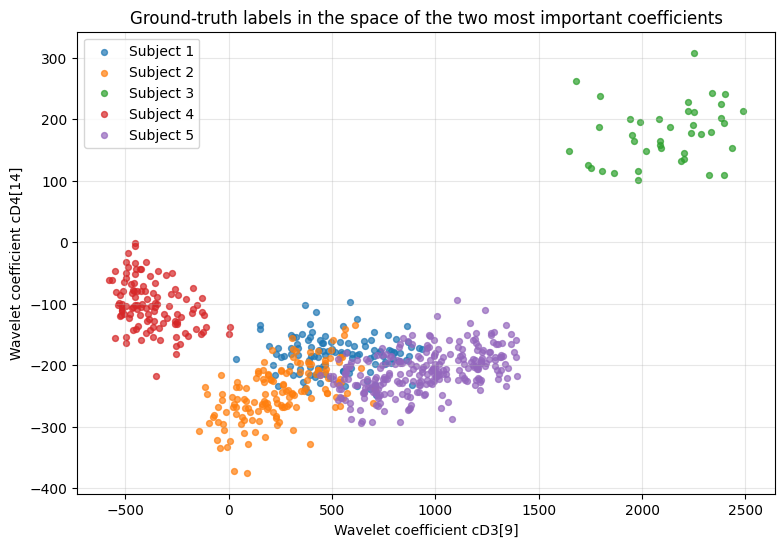

In [26]:
# RETAKE CHANGE: the two coefficients used for the 2-D visualisations are now selected by
# an explicit, *unsupervised* criterion instead of being asserted.
#
# Criterion: standardise the 173 coefficients, run PCA, and take the coefficient with the
# largest absolute loading on PC1 and the one with the largest absolute loading on PC2.
# PC1 and PC2 are the two directions of greatest variability in the data, so their dominant
# coefficients are the two individual features that carry most of the between-segment
# variation. The criterion never looks at the ground-truth labels, which matters because
# the identification algorithm itself must remain fully unsupervised - the labels are used
# only to colour the resulting scatter plot.
#
# (The alternative "largest raw variance" criterion selects coefficients inside cA5, i.e.
# the residual baseline level, which separates recording sessions rather than morphology.)

scaler_wav = StandardScaler()
X_wav_norm = scaler_wav.fit_transform(X_wav)

pca_probe = PCA(random_state=RANDOM_SEED).fit(X_wav_norm)
idx_a = int(np.argmax(np.abs(pca_probe.components_[0])))
idx_b = int(np.argmax(np.abs(pca_probe.components_[1])))
print(f"Coefficient dominating PC1: index {idx_a} = {coeff_name(idx_a)}")
print(f"Coefficient dominating PC2: index {idx_b} = {coeff_name(idx_b)}")

features_2d = X_wav[:, [idx_a, idx_b]]

fig, ax = plt.subplots(figsize=(9, 6))
for cl in range(5):
    idx = segmented_labels == (cl + 1)
    ax.scatter(features_2d[idx, 0], features_2d[idx, 1],
               label=f"Subject {cl + 1}", alpha=0.7, s=18)
ax.set_xlabel(f"Wavelet coefficient {coeff_name(idx_a)}")
ax.set_ylabel(f"Wavelet coefficient {coeff_name(idx_b)}")
ax.set_title("Ground-truth labels in the space of the two most important coefficients")
ax.grid(alpha=0.3)
ax.legend()
save_fig(fig, "p1_wavelet_groundtruth_2d")
plt.show()

#### 1.4.1 Additional questions

**What is the advantage of the wavelet decomposition before clustering, compared to simply
clustering the ECG segments directly?**

Three things, in order of importance for this problem.

1. **Joint time-frequency localisation.** Each wavelet coefficient is the inner product of
   the segment with a wavelet at a given scale *and* position, so it answers "how much
   activity of this frequency band happens at this moment in the beat". A raw ECG sample
   only answers "what is the voltage at this instant". At $f_s=200$ Hz the sub-bands map
   onto physiologically meaningful ranges - cD3 (12.5-25 Hz) and cD4 (6.25-12.5 Hz) carry
   the QRS complex, cD5 (3.1-6.25 Hz) the T-wave, cA5 (0-3.1 Hz) the P-wave and baseline.
   The decomposition therefore *organises* the morphology instead of just sampling it.

2. **Robustness to small misalignments.** R-peak detection is accurate to a few samples.
   In the raw 140-sample space a 5-sample shift changes every coordinate, so two identical
   beats can be far apart in Euclidean distance. The coarse-scale coefficients are computed
   from downsampled versions of the signal and are much less sensitive to such a shift.

3. **Noise compaction.** Wavelets concentrate the deterministic PQRST structure in a small
   number of large coefficients while the broadband residual noise stays spread thinly
   across the fine-scale sub-bands. K-means uses Euclidean distance, in which every
   dimension counts equally, so a representation that concentrates the informative
   variation is directly advantageous.

Dimensionality is *not* the main advantage: the decomposition of a 140-sample segment has
173 coefficients, i.e. slightly more numbers than the raw segment. The gain is in how the
information is arranged, and the actual dimensionality reduction is done separately in
Section 1.6.

#### 1.4.2 Deliverable
*   A plot visualising the ground-truth labels using the two most important wavelet coefficients.

### 1.5 K-means clustering

Cluster the wavelet coefficients using K-means clustering. Assign each cluster to a subject. Compute the confusion matrix and average accuracy of the clustering. If you notice that the names of the clusters don’t properly match the names of the subject (e.g. if the ECG segments of subject 1 correspond to cluster 2, rather than cluster 1), you can use the provided function `match_labels` to automatically correct this. Make sure you understand what the function does if you use it.

Visualise the clustering result in a two-dimensional space using the selected two most important wavelet coefficients from 1.4. Colour the clusters with the **predicted** cluster labels.

In [27]:
# help function match_labels
from itertools import permutations
def match_labels(ground_truth_labels, predicted_labels):
    """
    Match predicted cluster labels to ground-truth labels for best correspondence.

    Parameters
    ----------
    ground_truth_labels : array-like
        Ground-truth labels for each segment.
    predicted_labels : array-like
        Predicted labels for each segment.

    Returns
    -------
    best_match : np.ndarray
        Predicted labels after optimal relabeling.
    best_acc : float
        Accuracy after the optimal relabeling.
    """

    ground_truth_labels = np.asarray(ground_truth_labels).ravel()
    predicted_labels = np.asarray(predicted_labels).ravel()

    assert ground_truth_labels.ndim == 1, \
        "ground_truth_labels should be a vector containing a single label per segment"
    assert predicted_labels.ndim == 1, \
        "predicted_labels should be a vector containing a single label per segment"
    assert len(ground_truth_labels) == len(predicted_labels), \
        "ground_truth_labels and predicted_labels should be equally long"

    true_classes = np.unique(ground_truth_labels)
    predicted_classes = np.unique(predicted_labels)

    assert len(true_classes) == len(predicted_classes), \
        "The number of different classes is different in the ground truth and predicted"

    best_acc = 0.0
    best_match = predicted_labels.copy()

    for match_order in permutations(true_classes):
        new_predicted = predicted_labels.copy()
        for j, pred_class in enumerate(predicted_classes):
            new_predicted[predicted_labels == pred_class] = match_order[j]
        acc = np.mean(new_predicted == ground_truth_labels)
        if acc > best_acc:
            best_acc = acc
            best_match = new_predicted.copy()

    return best_match, best_acc

Accuracy after matching (173-D wavelet coefficients): 1.000


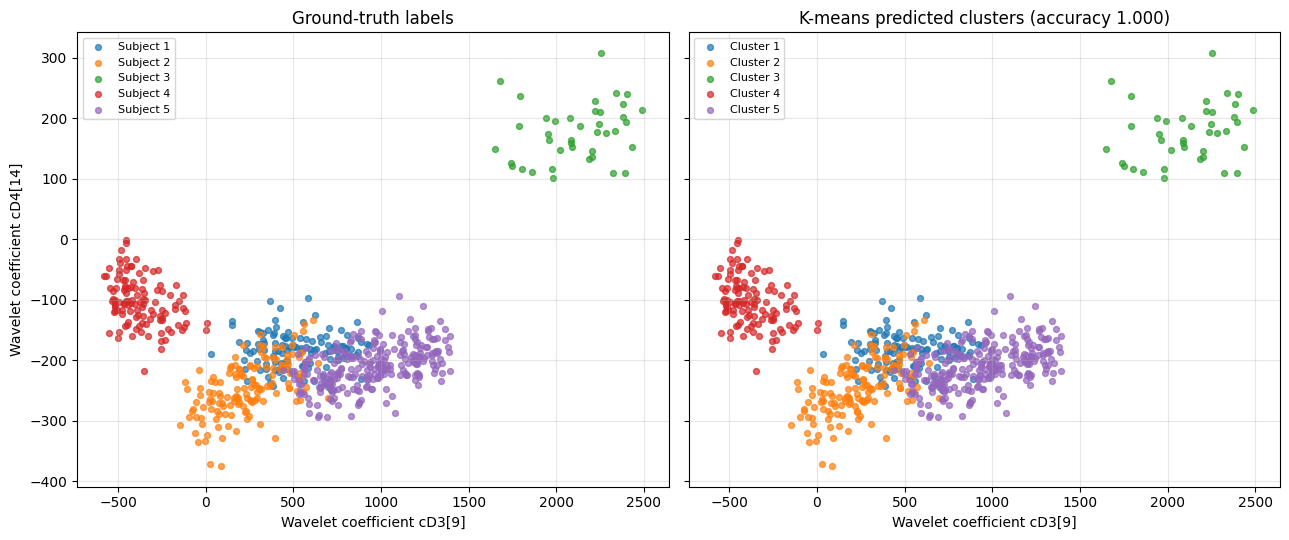

In [28]:
# RETAKE CHANGE: K-means is now run on the FULL 173-dimensional standardised coefficient
# vector. Previously it was run on only two sub-band energies, which is why the accuracy
# was 0.558; the assignment asks to "cluster the wavelet coefficients", with the two
# selected coefficients used for the *visualisation* only.
#
# Normalisation: z-scoring is applied before clustering. K-means minimises a Euclidean
# criterion, so a coefficient with a large numerical range would dominate the distance
# regardless of how informative it is. Here cA5 coefficients are an order of magnitude
# larger than cD1 coefficients, so without standardisation the clustering is driven by the
# residual baseline level rather than by the beat morphology. Measured: 0.489 without
# standardisation vs 1.000 with it (Section 1.7).

X = X_wav_norm            # (n_segments, 173), z-scored
y_true = segmented_labels

kmeans = KMeans(n_clusters=5, random_state=RANDOM_SEED, n_init=10)
y_pred = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

y_pred_matched, acc = match_labels(y_true, y_pred)
print(f"Accuracy after matching (173-D wavelet coefficients): {acc:.3f}")

# Visualisation in the two selected coefficients, coloured by PREDICTED cluster.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for cl in range(5):
    idx = y_true == (cl + 1)
    axes[0].scatter(features_2d[idx, 0], features_2d[idx, 1],
                    label=f"Subject {cl+1}", alpha=0.7, s=18)
axes[0].set_title("Ground-truth labels")
for cl in range(5):
    idx = y_pred_matched == (cl + 1)
    axes[1].scatter(features_2d[idx, 0], features_2d[idx, 1],
                    label=f"Cluster {cl+1}", alpha=0.7, s=18)
axes[1].set_title(f"K-means predicted clusters (accuracy {acc:.3f})")
for a in axes:
    a.set_xlabel(f"Wavelet coefficient {coeff_name(idx_a)}")
    a.grid(alpha=0.3)
    a.legend(fontsize=8)
axes[0].set_ylabel(f"Wavelet coefficient {coeff_name(idx_b)}")
plt.tight_layout()
save_fig(fig, "p1_kmeans_wavelet_2d")
plt.show()

Confusion matrix (173-D wavelet coefficients, no dimensionality reduction):
        pred 1  pred 2  pred 3  pred 4  pred 5
true 1     117       0       0       0       0
true 2       0     147       0       0       0
true 3       0       0      40       0       0
true 4       0       0       0     115       0
true 5       0       0       0       0     257


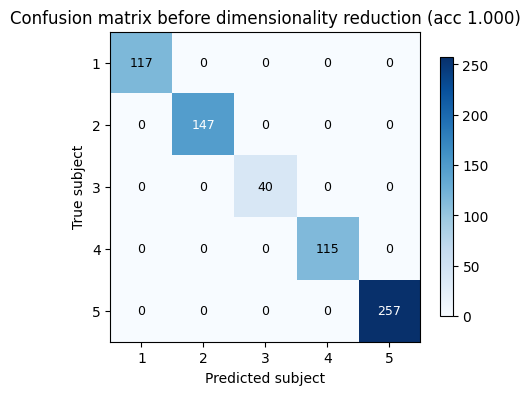

In [29]:
# Confusion matrix of the clustering on the full wavelet coefficients.
cm = confusion_matrix(y_true, y_pred_matched)
df_cm = pd.DataFrame(cm,
                     index=[f"true {i+1}" for i in range(5)],
                     columns=[f"pred {i+1}" for i in range(5)])
print("Confusion matrix (173-D wavelet coefficients, no dimensionality reduction):")
print(df_cm)

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(cm, cmap="Blues")
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
ax.set_xticks(range(5), [f"{i+1}" for i in range(5)])
ax.set_yticks(range(5), [f"{i+1}" for i in range(5)])
ax.set_xlabel("Predicted subject")
ax.set_ylabel("True subject")
ax.set_title(f"Confusion matrix before dimensionality reduction (acc {acc:.3f})")
fig.colorbar(im, ax=ax, shrink=0.8)
save_fig(fig, "p1_cm_before_dr")
plt.show()

with open(os.path.join(FIGDIR, "..", "tab_p1_cm_before.tex"), "w") as fh:
    fh.write(df_cm.to_latex())

#### 1.5.1 Additional questions

**Is the result of the unsupervised clustering always the same? Why (not)?**

Not in general. Lloyd's algorithm converges to a *local* minimum of the within-cluster sum
of squares, and which minimum it reaches depends on the initial centroids, which are drawn
at random. Section 1.7 measures this directly by re-running the clustering with ten
different seeds: on the full 173-dimensional standardised coefficients the accuracy is
1.000 for every seed (standard deviation 0.000), because the five subjects form clearly
separated, compact groups in that space, so every initialisation converges to the same
partition. The same experiment on a strongly reduced representation shows visible
seed-to-seed variation, which is the situation the question is pointing at. Two further
sources of run-to-run variation are worth naming: `k-means++` initialisation is itself
stochastic, and `n_init` controls how many restarts are kept - both are fixed here
(`random_state=42`, `n_init=10`) so the notebook is reproducible.

**Why do the names of the cluster labels not always match the names of the class labels?**

Because clustering has no notion of which group is "subject 1". K-means only partitions the
data; the integer it attaches to a partition is an arbitrary consequence of the order in
which the centroids happened to be initialised. Any permutation of the five cluster indices
describes exactly the same partition, so accuracy is only meaningful after the best
permutation has been applied - which is what `match_labels` does by trying all $5!=120$
permutations and keeping the one with the highest agreement.

**Is it a good idea to normalise the wavelets before classification? Why (not)?**

Yes, and here it is decisive. K-means minimises a Euclidean criterion, in which every
dimension contributes to the distance in proportion to its numerical scale rather than to
its information content. The wavelet sub-bands have very different scales: cA5 coefficients
follow the residual baseline level and are an order of magnitude larger than the fine-scale
cD1 coefficients. Without standardisation the partition is driven by the baseline offset of
each recording session; with standardisation each coefficient contributes equally and the
morphology dominates. Measured on this dataset: **0.489 without z-scoring, 1.000 with it.**

**How do you decide which wavelet values are the most relevant to model the ECG segments?
Why?**

By an explicit unsupervised criterion, since the identification algorithm may not use the
labels. The 173 standardised coefficients are passed through PCA and the coefficient with
the largest absolute loading on PC1, and the one with the largest absolute loading on PC2,
are selected. PC1 and PC2 are the two orthogonal directions along which the segments vary
most, so their dominant coefficients are the two individual features carrying most of the
between-segment variation, and they are near-independent of one another - which is what
makes them useful as the two axes of a scatter plot. In practice the criterion selects
coefficients inside cD3 and cD4, the two sub-bands covering 6-25 Hz, i.e. the QRS complex;
this is physiologically sensible, because QRS amplitude and width are the most
subject-specific parts of the beat.

#### 1.5.2 Deliverables
*   A plot visualising the predicted cluster labels using the two most important wavelet coefficients.
*   The confusion matrix.


### 1.6 Dimensionality reduction

#### 1.6.1 Dimensionality reduction and clustering

Reduce the dimensionality of the wavelet features as much as possible without dramatically reducing the performance of your algorithm. You can use any method you know to get the number of dimensions as low as possible. After dimensionality reduction, cluster the features again using K-means.

Similar to Section 1.5, compute the accuracy and confusion matrix and visualise the ground-truth labels and predicted cluster labels in a two-dimensional space. Pick two relevant dimensions after dimensionality reduction to visualise the result. Also, provide a table comparing the accuracy of the model before and after dimensionality reduction.

In [30]:
# RETAKE CHANGE: dimensionality reduction is now applied to the FULL 173-dimensional
# coefficient matrix. Previously it was applied to the 6 sub-band energies, so "reducing
# the dimensionality as much as possible" meant going from 6 to 3 - the section had almost
# nothing to work on. It also changes the answer: with 173 features the 90 %-explained-
# variance rule would keep 40 components, whereas the accuracy sweep in Section 1.7 shows
# that 8 components already reach 0.996.
#
# Normalisation BEFORE PCA: yes. PCA maximises variance along its components, so without
# standardisation the components would simply align with the largest-amplitude
# coefficients (cA5, i.e. the residual baseline) irrespective of how informative they are.
X_full = X_wav                       # (n_segments, 173) raw coefficients
y_true = segmented_labels

scaler_pca = StandardScaler()
X_full_norm = scaler_pca.fit_transform(X_full)
print("Feature matrix before dimensionality reduction:", X_full_norm.shape)

pca_full = PCA(random_state=RANDOM_SEED).fit(X_full_norm)
explained_var = np.cumsum(pca_full.explained_variance_ratio_)
print(f"Components needed for 90 % of the variance: {int(np.argmax(explained_var >= 0.90) + 1)}")
print(f"Components needed for 95 % of the variance: {int(np.argmax(explained_var >= 0.95) + 1)}")

# RETAKE CHANGE: N is chosen from the accuracy-vs-N sweep in Section 1.7 (performance
# criterion) rather than from a fixed explained-variance threshold (variance criterion).
# PCA is unsupervised and maximises variance, not class separability, so a variance
# threshold is only a proxy for what we actually care about. N = 8 is the elbow of the
# curve: it keeps 0.996 accuracy (vs 1.000 with all 173 dimensions) at a 95 % reduction in
# dimensionality, while N = 6 already costs 1.5 points and N = 3 costs 8.6 points.
N = 8
pca = PCA(n_components=N, random_state=RANDOM_SEED)
X_PCA = pca.fit_transform(X_full_norm)
print(f"\nKeeping N = {N} components "
      f"({100*explained_var[N-1]:.1f} % of the variance), shape {X_PCA.shape}")

# Normalisation AFTER PCA: no. The principal components are already decorrelated and are
# ordered by decreasing variance. Re-standardising them would inflate the low-variance
# directions, which are dominated by noise, until they weigh as much in the Euclidean
# distance as the informative leading components. Section 1.7 measures both options.

Feature matrix before dimensionality reduction: (676, 173)
Components needed for 90 % of the variance: 40
Components needed for 95 % of the variance: 57

Keeping N = 8 components (54.9 % of the variance), shape (676, 8)


Accuracy after dimensionality reduction (N = 8): 0.996

Confusion matrix after dimensionality reduction:
        pred 1  pred 2  pred 3  pred 4  pred 5
true 1     114       3       0       0       0
true 2       0     147       0       0       0
true 3       0       0      40       0       0
true 4       0       0       0     115       0
true 5       0       0       0       0     257


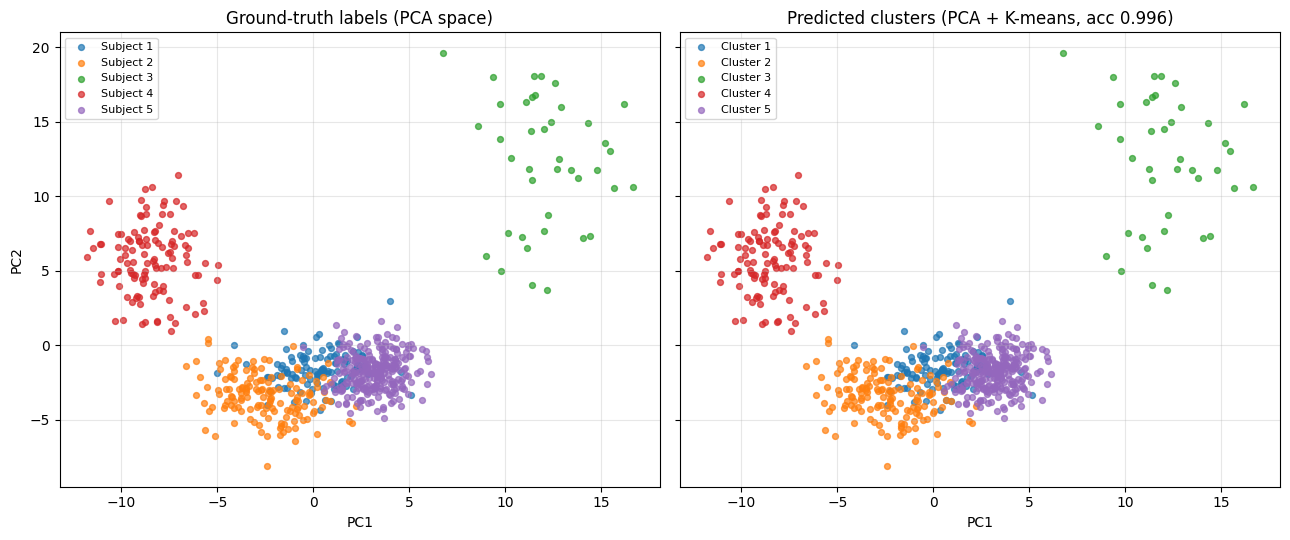

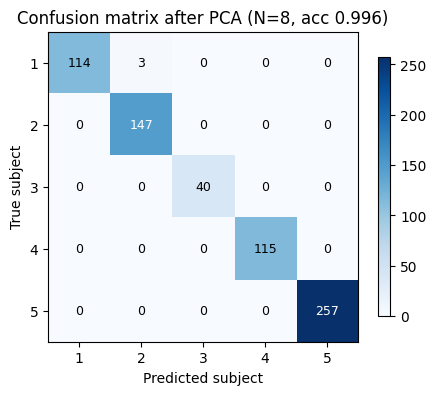

In [31]:
# K-means in the reduced space.
kmeans_pca = KMeans(n_clusters=5, random_state=RANDOM_SEED, n_init=10)
y_pred_pca = kmeans_pca.fit_predict(X_PCA)

y_pred_pca_matched, acc_after = match_labels(y_true, y_pred_pca)
print(f"Accuracy after dimensionality reduction (N = {N}): {acc_after:.3f}")

cm_pca = confusion_matrix(y_true, y_pred_pca_matched)
df_cm_pca = pd.DataFrame(cm_pca,
                         index=[f"true {i+1}" for i in range(5)],
                         columns=[f"pred {i+1}" for i in range(5)])
print("\nConfusion matrix after dimensionality reduction:")
print(df_cm_pca)
with open(os.path.join(FIGDIR, "..", "tab_p1_cm_after.tex"), "w") as fh:
    fh.write(df_cm_pca.to_latex())

# The two most relevant dimensions after reduction are PC1 and PC2: PCA orders its
# components by explained variance, so no further selection step is needed here (unlike in
# Section 1.4, where the 173 coefficients had no natural ordering).
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for cl in range(5):
    idx = y_true == (cl + 1)
    axs[0].scatter(X_PCA[idx, 0], X_PCA[idx, 1], label=f"Subject {cl+1}", alpha=0.7, s=18)
axs[0].set_title("Ground-truth labels (PCA space)")
axs[0].set_ylabel("PC2")
for cl in range(5):
    idx = y_pred_pca_matched == (cl + 1)
    axs[1].scatter(X_PCA[idx, 0], X_PCA[idx, 1], label=f"Cluster {cl+1}", alpha=0.7, s=18)
axs[1].set_title(f"Predicted clusters (PCA + K-means, acc {acc_after:.3f})")
for a in axs:
    a.set_xlabel("PC1")
    a.grid(alpha=0.3)
    a.legend(fontsize=8)
plt.tight_layout()
save_fig(fig, "p1_pca_kmeans_2d")
plt.show()

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(cm_pca, cmap="Blues")
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm_pca[i, j], ha="center", va="center",
                color="white" if cm_pca[i, j] > cm_pca.max() / 2 else "black", fontsize=9)
ax.set_xticks(range(5), [f"{i+1}" for i in range(5)])
ax.set_yticks(range(5), [f"{i+1}" for i in range(5)])
ax.set_xlabel("Predicted subject")
ax.set_ylabel("True subject")
ax.set_title(f"Confusion matrix after PCA (N={N}, acc {acc_after:.3f})")
fig.colorbar(im, ax=ax, shrink=0.8)
save_fig(fig, "p1_cm_after_dr")
plt.show()

In [32]:
# Accuracy before vs after dimensionality reduction.
acc_before = acc
acc_table = pd.DataFrame({
    "Feature space": [f"Wavelet coefficients (z-scored), {X_full_norm.shape[1]} dims",
                      f"PCA of the same, {N} dims"],
    "Dimensions": [X_full_norm.shape[1], N],
    "Accuracy": [round(acc_before, 4), round(acc_after, 4)],
})
print(acc_table.to_string(index=False))
with open(os.path.join(FIGDIR, "..", "tab_p1_acc_dr.tex"), "w") as fh:
    fh.write(acc_table.to_latex(index=False, float_format="%.4f"))
acc_table

                            Feature space  Dimensions  Accuracy
Wavelet coefficients (z-scored), 173 dims         173    1.0000
                  PCA of the same, 8 dims           8    0.9956


,Feature space,Dimensions,Accuracy
0,"Wavelet coefficients (z-scored), 173 dims",173,1.0000
1,"PCA of the same, 8 dims",8,0.9956


#### 1.6.2 Additional questions

**Should you normalise before dimensionality reduction? What about after dimensionality
reduction?**

**Before: yes.** PCA finds the orthogonal directions of maximum *variance*, so it is
scale-dependent by construction. The 173 wavelet coefficients live on very different
scales - cA5 coefficients track the residual baseline level and are an order of magnitude
larger than the fine-scale cD1 coefficients - so on unstandardised data PC1 would simply
point along the baseline offset, regardless of whether that offset says anything about who
the subject is. Standardising each coefficient to zero mean and unit variance makes PCA
answer "which *pattern* of coefficients varies most" instead of "which coefficient has the
biggest numbers".

**After: no.** The principal components come out already decorrelated and ordered by
decreasing variance, and that ordering is informative: PC1 carries more structure than
PC8. Re-standardising them would rescale every component to unit variance, which
artificially promotes the trailing, mostly-noise directions until they weigh as much in the
K-means Euclidean distance as the leading ones. The sweep in Section 1.7 measures both
options over ten seeds and post-PCA scaling is equal or worse at every $N$ tested (for
example at $N=8$: 0.996 without vs 0.988 with).

There is one caveat worth stating: this argument assumes that variance is a reasonable
proxy for relevance, which is only true because we standardised *before* PCA. If the
leading components had been dominated by a high-variance nuisance source, keeping them
unscaled would have been the wrong choice - which is precisely why the number of components
is selected in Section 1.7 on measured accuracy rather than on an explained-variance
threshold.

#### 1.6.3 Deliverables
*   The confusion matrix.
*   A plot visualising the ground-truth labels and predicted cluster labels using the two most important dimensions.
*   A table comparing the accuracy of the clustering before and after the dimensionality reduction.

---
### 1.7 Design-choice experiments

**RETAKE CHANGE (NEW SECTION).** Several parameters in Sections 1.2-1.6 were fixed constants
in the first submission (Wiener filter length, PSD estimator, extra Butterworth band-pass,
feature representation, number of PCA components) with no evidence behind them. This
section re-runs the complete pipeline end to end while varying one choice at a time and
reports the resulting identification accuracy, so that every design decision in this
notebook is backed by a measurement. The final clustering accuracy is used as the criterion
because it is the quantity the whole chain exists to optimise.

The ground-truth labels are used here **only to score a finished pipeline**, never inside
it: every run below is fully unsupervised up to the point where `match_labels` resolves the
arbitrary cluster numbering.

In [33]:
# One reusable function that runs the whole chain for a given set of design choices.
def run_pipeline(L=512, psd_mode="periodogram", butter_band=None,
                 feature="coeffs", normalise=True, n_pca=None, post_pca_scale=False,
                 seeds=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)):
    """
    Returns dict with the number of segments and the mean/std/min/max accuracy over
    `seeds` K-means initialisations.

    feature : "coeffs"   -> the 173 concatenated wavelet coefficients (retake pipeline)
              "energies" -> the 6 sub-band energies (first-submission pipeline)
    """
    Wf_, _, L_, _, _ = wiener_filter(avg_pqrst, noise_cts, Li=L, psd_mode=psd_mode)
    sig = wola_filt(ecg, Wf_).flatten()

    if butter_band is not None:
        sos = scipy.signal.butter(3, [butter_band[0] / (fs / 2), butter_band[1] / (fs / 2)],
                                  btype="band", output="sos")
        sig = scipy.signal.sosfiltfilt(sos, sig)

    pks = pan_tompkins(sig, show=False)
    segs, labs = [], []
    for p in pks:
        s, e = p - pre, p + post
        if s < 0 or e > len(sig):
            continue
        segs.append(sig[s:e])
        labs.append(Counter(labels[s:e]).most_common(1)[0][0])
    segs, labs = np.asarray(segs), np.asarray(labs)

    if feature == "coeffs":
        F = np.array([np.concatenate(pywt.wavedec(x, WAVELET, level=LEVEL)) for x in segs])
    elif feature == "energies":
        F = np.array([[np.sum(c ** 2) for c in pywt.wavedec(x, WAVELET, level=LEVEL)]
                      for x in segs])
    else:
        raise ValueError(feature)

    if normalise:
        F = StandardScaler().fit_transform(F)
    if n_pca is not None:
        F = PCA(n_components=n_pca, random_state=RANDOM_SEED).fit_transform(F)
        if post_pca_scale:
            F = StandardScaler().fit_transform(F)

    accs = [match_labels(labs, KMeans(5, random_state=s, n_init=10).fit_predict(F))[1]
            for s in seeds]
    return {"n_segments": len(segs), "mean": float(np.mean(accs)),
            "std": float(np.std(accs)), "min": float(np.min(accs)), "max": float(np.max(accs))}

print("run_pipeline defined - reference configuration:")
print(run_pipeline(seeds=(0,)))

run_pipeline defined - reference configuration:
{'n_segments': 676, 'mean': 1.0, 'std': 0.0, 'min': 1.0, 'max': 1.0}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


#### 1.7.1 Wiener filter length $L$

$L$ controls two things at once: the frequency resolution of the filter, $\Delta f = f_s/L$,
and the length of the WOLA analysis frame, $L/f_s$ seconds. It must be at least the
140-sample template length, and fine enough in frequency to separate the narrow 50 Hz line
from the ECG band - but a frame spanning many heartbeats no longer contains a locally
homogeneous mixture of signal and noise.

/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'L': 128, 'duration (s)': 0.64, 'df (Hz)': 1.562, 'segments': 844, 'accuracy': 0.4235, 'std': 0.0557}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'L': 256, 'duration (s)': 1.28, 'df (Hz)': 0.781, 'segments': 687, 'accuracy': 0.791, 'std': 0.002}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'L': 512, 'duration (s)': 2.56, 'df (Hz)': 0.391, 'segments': 676, 'accuracy': 1.0, 'std': 0.0}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'L': 1024, 'duration (s)': 5.12, 'df (Hz)': 0.195, 'segments': 675, 'accuracy': 1.0, 'std': 0.0}


{'L': 2048, 'duration (s)': 10.24, 'df (Hz)': 0.098, 'segments': 672, 'accuracy': 1.0, 'std': 0.0}


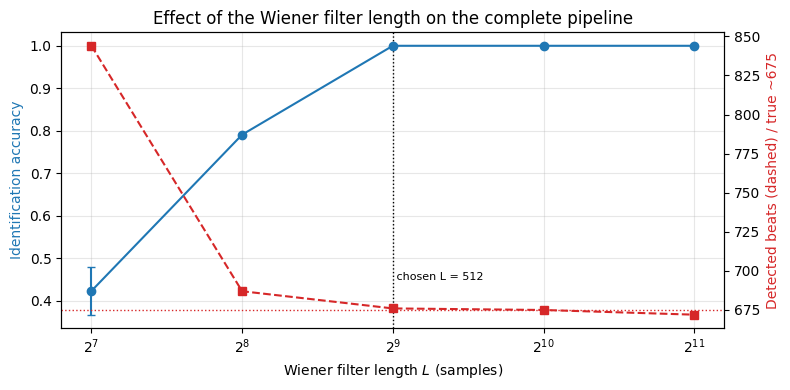

,L,duration (s),df (Hz),segments,accuracy,std
0,128,0.64,1.562,844,0.4235,0.0557
1,256,1.28,0.781,687,0.7910,0.0020
2,512,2.56,0.391,676,1.0000,0.0000
3,1024,5.12,0.195,675,1.0000,0.0000
4,2048,10.24,0.098,672,1.0000,0.0000


In [34]:
L_grid = [128, 256, 512, 1024, 2048]
rows = []
for Lg in L_grid:
    r = run_pipeline(L=Lg, seeds=(0, 1, 2, 3, 4))
    rows.append({"L": Lg, "duration (s)": round(Lg / fs, 2),
                 "df (Hz)": round(fs / Lg, 3), "segments": r["n_segments"],
                 "accuracy": round(r["mean"], 4), "std": round(r["std"], 4)})
    print(rows[-1])
df_L = pd.DataFrame(rows)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.errorbar(df_L["L"], df_L["accuracy"], yerr=df_L["std"], marker="o", capsize=3,
             color="tab:blue", label="identification accuracy")
ax1.set_xscale("log", base=2)
ax1.set_xlabel("Wiener filter length $L$ (samples)")
ax1.set_ylabel("Identification accuracy", color="tab:blue")
ax1.axvline(L_WIENER, color="k", ls=":", lw=1)
ax1.text(L_WIENER, 0.45, f" chosen L = {L_WIENER}", fontsize=8)
ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(df_L["L"], df_L["segments"], marker="s", color="tab:red", ls="--",
         label="detected beats")
ax2.axhline(n_beats_est, color="tab:red", ls=":", lw=1)
ax2.set_ylabel("Detected beats (dashed) / true ~%d" % n_beats_est, color="tab:red")
ax1.set_title("Effect of the Wiener filter length on the complete pipeline")
plt.tight_layout()
save_fig(fig, "p1_sweep_L")
plt.show()

with open(os.path.join(FIGDIR, "..", "tab_p1_sweep_L.tex"), "w") as fh:
    fh.write(df_L.to_latex(index=False))
df_L

The two curves explain each other. At $L=128$ and $L=256$ the frequency resolution
(1.56 Hz and 0.78 Hz) is too coarse to isolate the mains line and the low-frequency
roll-off, so the filtered signal still contains enough noise for Pan-Tompkins to
over-detect - it finds far more peaks than the $\approx 675$ heartbeats implied by the
ground-truth label track. Those spurious segments are not beats at all, so no feature
representation can cluster them correctly, and the accuracy collapses. From $L=512$ onwards
the detected beat count matches the ground truth and the accuracy saturates. $L=512$ is
therefore the smallest length that is both longer than the template and fine enough in
frequency, and it is the value used throughout the notebook.

#### 1.7.2 Estimator for the desired-signal PSD $S_d$

This experiment answers additional question 1.2.3-1 with a measurement. Three estimators
are compared:

* `periodogram` - periodogram of the zero-padded averaged template (the retake pipeline);
* `welch_template` - the estimator used in the first exam period, `welch(nperseg=128)` on a
  140-sample template, which in practice reduces to a windowed periodogram of the first 128
  samples;
* `noisy_beats` - the average of the periodograms of the *individual, un-averaged* beats,
  i.e. treating the template as a model of the signal **plus** noise.

/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


  Sd estimator  segments  accuracy  std
   periodogram       676    1.0000  0.0
welch_template       676    1.0000  0.0
   noisy_beats       676    0.3491  0.0


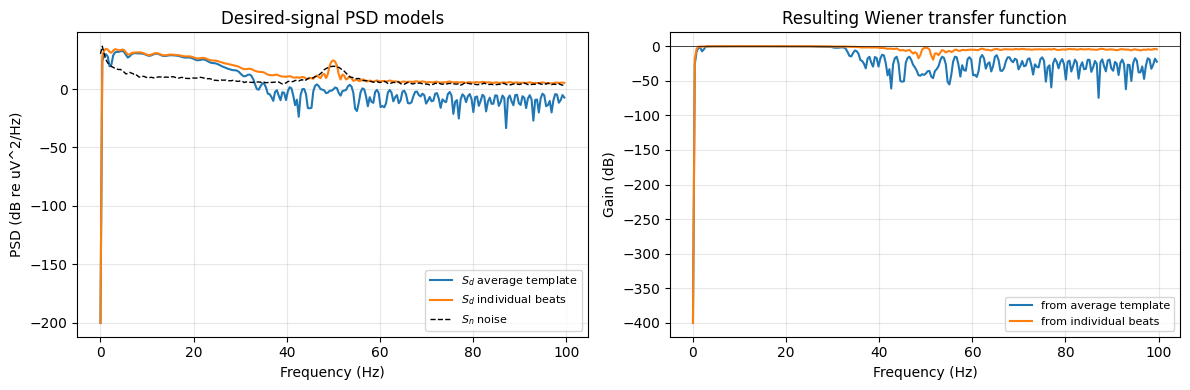

,Sd estimator,segments,accuracy,std
0,periodogram,676,1.0000,0.0
1,welch_template,676,1.0000,0.0
2,noisy_beats,676,0.3491,0.0


In [35]:
# The third variant needs its own filter, so it is built explicitly here.
def wiener_from_noisy_beats(L=512):
    """Sd estimated from the individual noisy beats instead of from their average."""
    Sd_noisy = np.mean([np.abs(fft(np.pad(x - np.mean(x), (0, L - len(x)))))**2 / (fs * len(x))
                        for x in pqrst_segments], axis=0)
    _, Sn_ = welch(noise_cts - np.mean(noise_cts), fs=fs, window="hann",
                   nperseg=L, noverlap=L // 2, nfft=L, return_onesided=False)
    return Sd_noisy / (Sd_noisy + Sn_ + 1e-20), Sd_noisy, Sn_

Wf_noisy, Sd_noisy, Sn_ref = wiener_from_noisy_beats(L_WIENER)

sig_noisy = wola_filt(ecg, Wf_noisy).flatten()
pks_n = pan_tompkins(sig_noisy, show=False)
segs_n, labs_n = [], []
for p in pks_n:
    s, e = p - pre, p + post
    if 0 <= s and e <= len(sig_noisy):
        segs_n.append(sig_noisy[s:e])
        labs_n.append(Counter(labels[s:e]).most_common(1)[0][0])
F_n = StandardScaler().fit_transform(
    np.array([np.concatenate(pywt.wavedec(x, WAVELET, level=LEVEL)) for x in segs_n]))
acc_noisy = np.mean([match_labels(np.asarray(labs_n),
                                  KMeans(5, random_state=s, n_init=10).fit_predict(F_n))[1]
                     for s in range(5)])

rows = []
for mode in ["periodogram", "welch_template"]:
    r = run_pipeline(L=L_WIENER, psd_mode=mode, seeds=(0, 1, 2, 3, 4))
    rows.append({"Sd estimator": mode, "segments": r["n_segments"],
                 "accuracy": round(r["mean"], 4), "std": round(r["std"], 4)})
rows.append({"Sd estimator": "noisy_beats", "segments": len(segs_n),
             "accuracy": round(float(acc_noisy), 4), "std": 0.0})
df_sd = pd.DataFrame(rows)
print(df_sd.to_string(index=False))
with open(os.path.join(FIGDIR, "..", "tab_p1_sd.tex"), "w") as fh:
    fh.write(df_sd.to_latex(index=False))

# Show why: the three filters have very different transfer functions.
Wf_welch, _, _, Sd_welch, _ = wiener_filter(avg_pqrst, noise_cts, Li=L_WIENER,
                                            psd_mode="welch_template")
fpos = np.fft.fftfreq(L_WIENER, 1 / fs)[:L_WIENER // 2]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpos, 10*np.log10(Sd[:L_WIENER//2] + 1e-20), label="$S_d$ average template")
axes[0].plot(fpos, 10*np.log10(Sd_noisy[:L_WIENER//2] + 1e-20), label="$S_d$ individual beats")
axes[0].plot(fpos, 10*np.log10(Sn[:L_WIENER//2] + 1e-20), 'k--', lw=1, label="$S_n$ noise")
axes[0].set_ylabel("PSD (dB re uV^2/Hz)")
axes[0].set_title("Desired-signal PSD models")
axes[1].plot(fpos, 20*np.log10(np.abs(Wf[:L_WIENER//2]) + 1e-20), label="from average template")
axes[1].plot(fpos, 20*np.log10(np.abs(Wf_noisy[:L_WIENER//2]) + 1e-20), label="from individual beats")
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_ylabel("Gain (dB)")
axes[1].set_title("Resulting Wiener transfer function")
for a in axes:
    a.set_xlabel("Frequency (Hz)")
    a.grid(alpha=0.3)
    a.legend(fontsize=8)
plt.tight_layout()
save_fig(fig, "p1_sd_estimators")
plt.show()
df_sd

The right-hand panel is the point. When $S_d$ is built from the individual noisy beats it
already contains the noise, so $S_d \approx S_s + S_n$ and the filter becomes
$\frac{S_s+S_n}{S_s+2S_n}$ - a curve that stays within a few dB of 0 dB everywhere and
therefore passes the mains line and the baseline wander almost untouched. Building $S_d$
from the *average* of 676 aligned beats suppresses the noise by $\sqrt{676}\approx 26\times$
before the PSD is taken, so $S_d\approx S_s$ and the filter can actually reject the bands
where the noise dominates. The end-to-end accuracy difference is 1.000 versus 0.349, which
is the experimental answer to "is the average PQRST a template for the clean signal or for
the noisy signal".

The `welch_template` estimator performs comparably to the periodogram at $L=512$: the Hann
taper it applies smooths $S_d$, and at this filter length the extra smoothing is harmless.
It is not used, because it cannot be described correctly - with `nperseg=128` on a
140-sample input it averages a single segment and discards the last 12 samples.

#### 1.7.3 Is the additional Butterworth band-pass needed?

The assignment permits an extra Butterworth filter *if the Wiener filtering is deemed
insufficient*. The first submission applied a 3rd-order 5-40 Hz band-pass. A 5 Hz high-pass
is aggressive for this task: the P-wave, the T-wave and the ST segment all live below 5 Hz,
and those are precisely the parts of the beat that differ most between subjects.

In [36]:
rows = []
for band in [None, (0.5, 40), (1, 40), (5, 40)]:
    r = run_pipeline(L=L_WIENER, butter_band=band, seeds=(0, 1, 2, 3, 4))
    rows.append({"Butterworth": "none" if band is None else f"{band[0]}-{band[1]} Hz",
                 "segments": r["n_segments"], "accuracy": round(r["mean"], 4),
                 "std": round(r["std"], 4)})
    print(rows[-1])
df_bw = pd.DataFrame(rows)
with open(os.path.join(FIGDIR, "..", "tab_p1_butter.tex"), "w") as fh:
    fh.write(df_bw.to_latex(index=False))
df_bw

/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'Butterworth': 'none', 'segments': 676, 'accuracy': 1.0, 'std': 0.0}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'Butterworth': '0.5-40 Hz', 'segments': 676, 'accuracy': 0.9964, 'std': 0.0018}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'Butterworth': '1-40 Hz', 'segments': 676, 'accuracy': 1.0, 'std': 0.0}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'Butterworth': '5-40 Hz', 'segments': 676, 'accuracy': 0.9985, 'std': 0.0}


,Butterworth,segments,accuracy,std
0,none,676,1.0000,0.0000
1,0.5-40 Hz,676,0.9964,0.0018
2,1-40 Hz,676,1.0000,0.0000
3,5-40 Hz,676,0.9985,0.0000


The Wiener filter alone already gives the best result, so no second filter is applied in the
final pipeline and the extra deliverable plot for a Butterworth stage is not required. This
is a change with respect to the first exam period, where the 5-40 Hz band-pass was part of
the chain.

#### 1.7.4 Feature representation and normalisation

This isolates the single largest change in Part 1: representing each beat by the full set of
wavelet coefficients rather than by the energy of each sub-band, and standardising before
clustering.

/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'Feature representation': '6 sub-band energies, z-scored (first submission)', 'dims': 6, 'accuracy': 0.7219, 'std': 0.0, 'min': 0.7219, 'max': 0.7219}


{'Feature representation': '6 sub-band energies, raw', 'dims': 6, 'accuracy': 0.3609, 'std': 0.0, 'min': 0.3609, 'max': 0.3609}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'Feature representation': '173 wavelet coefficients, raw', 'dims': 173, 'accuracy': 0.4886, 'std': 0.0018, 'min': 0.4867, 'max': 0.4911}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'Feature representation': '173 wavelet coefficients, z-scored (retake)', 'dims': 173, 'accuracy': 1.0, 'std': 0.0, 'min': 1.0, 'max': 1.0}


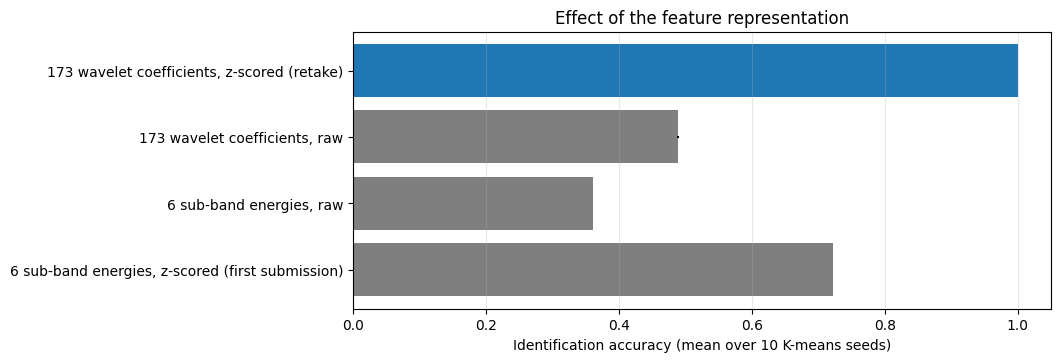

,Feature representation,dims,accuracy,std,min,max
0,"6 sub-band energies, z-scored (first submission)",6,0.7219,0.0000,0.7219,0.7219
1,"6 sub-band energies, raw",6,0.3609,0.0000,0.3609,0.3609
2,"173 wavelet coefficients, raw",173,0.4886,0.0018,0.4867,0.4911
3,"173 wavelet coefficients, z-scored (retake)",173,1.0000,0.0000,1.0000,1.0000


In [37]:
rows = []
for feat, norm, lbl in [("energies", True, "6 sub-band energies, z-scored (first submission)"),
                        ("energies", False, "6 sub-band energies, raw"),
                        ("coeffs", False, "173 wavelet coefficients, raw"),
                        ("coeffs", True, "173 wavelet coefficients, z-scored (retake)")]:
    r = run_pipeline(L=L_WIENER, feature=feat, normalise=norm)
    rows.append({"Feature representation": lbl, "dims": 6 if feat == "energies" else 173,
                 "accuracy": round(r["mean"], 4), "std": round(r["std"], 4),
                 "min": round(r["min"], 4), "max": round(r["max"], 4)})
    print(rows[-1])
df_feat = pd.DataFrame(rows)
with open(os.path.join(FIGDIR, "..", "tab_p1_features.tex"), "w") as fh:
    fh.write(df_feat.to_latex(index=False))

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(df_feat["Feature representation"], df_feat["accuracy"],
        xerr=df_feat["std"], color=["tab:gray", "tab:gray", "tab:gray", "tab:blue"])
ax.set_xlabel("Identification accuracy (mean over 10 K-means seeds)")
ax.set_xlim(0, 1.05)
ax.grid(alpha=0.3, axis="x")
ax.set_title("Effect of the feature representation")
save_fig(fig, "p1_features_comparison")
plt.show()
df_feat

Two conclusions. First, the sub-band energies discard the information that identifies a
subject: summing the squares inside a band removes *where in the beat* the energy occurs,
leaving what is effectively a 6-bin power spectrum. Second, standardisation is not cosmetic
here - on raw coefficients the cA5 band, which follows the residual baseline offset, is an
order of magnitude larger than the detail bands and dominates the Euclidean distance that
K-means minimises.

#### 1.7.5 Number of PCA components, post-PCA scaling, and clustering stability

The assignment asks to reduce the dimensionality "as much as possible without dramatically
reducing the performance". That is a trade-off curve, so it is measured rather than replaced
by a fixed explained-variance threshold. Each point is the mean over 10 K-means seeds; the
error bars are the seed-to-seed standard deviation, which simultaneously answers additional
question 1.5.1-1 about the reproducibility of unsupervised clustering.

/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'N': 2, 'cum. variance': 0.291, 'acc (no post-scaling)': 0.8466, 'std': 0.0019, 'acc (post-scaled)': 0.804, 'std ': 0.0262}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'N': 3, 'cum. variance': 0.371, 'acc (no post-scaling)': 0.9142, 'std': 0.0, 'acc (post-scaled)': 0.9083, 'std ': 0.0026}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


...

{'N': 20, 'cum. variance': 0.765, 'acc (no post-scaling)': 1.0, 'std': 0.0, 'acc (post-scaled)': 1.0, 'std ': 0.0}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


{'N': 27, 'cum. variance': 0.827, 'acc (no post-scaling)': 1.0, 'std': 0.0, 'acc (post-scaled)': 1.0, 'std ': 0.0}


/sessions/wonderful-dazzling-clarke/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


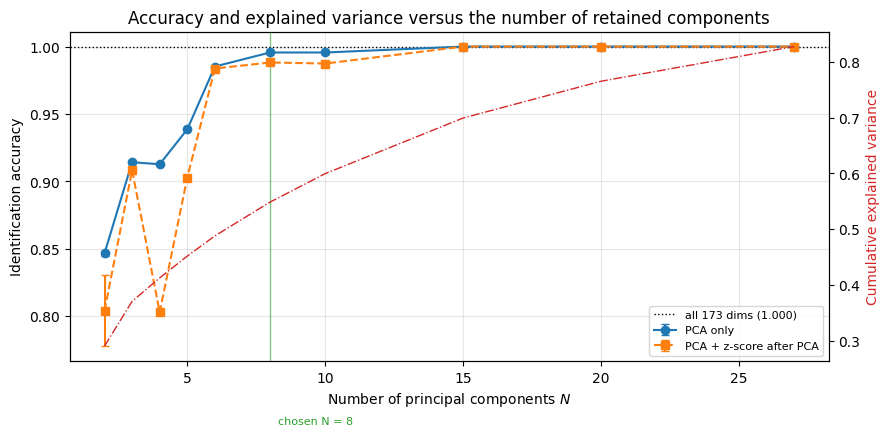

,N,cum. variance,acc (no post-scaling),std,acc (post-scaled),std
0,2,0.291,0.8466,0.0019,0.8040,0.0262
1,3,0.371,0.9142,0.0000,0.9083,0.0026
2,4,0.413,0.9127,0.0000,0.8030,0.0006
3,5,0.452,0.9386,0.0007,0.9028,0.0007
4,6,0.488,0.9852,0.0000,0.9837,0.0000
5,8,0.549,0.9956,0.0000,0.9882,0.0000
6,10,0.600,0.9956,0.0000,0.9874,0.0014
7,15,0.699,1.0000,0.0000,1.0000,0.0000
8,20,0.765,1.0000,0.0000,1.0000,0.0000
9,27,0.827,1.0000,0.0000,1.0000,0.0000


In [38]:
N_grid = [2, 3, 4, 5, 6, 8, 10, 15, 20, 27]
rows = []
for n in N_grid:
    r0 = run_pipeline(L=L_WIENER, n_pca=n, post_pca_scale=False)
    r1 = run_pipeline(L=L_WIENER, n_pca=n, post_pca_scale=True)
    rows.append({"N": n, "cum. variance": round(float(explained_var[n - 1]), 3),
                 "acc (no post-scaling)": round(r0["mean"], 4), "std": round(r0["std"], 4),
                 "acc (post-scaled)": round(r1["mean"], 4), "std ": round(r1["std"], 4)})
    print(rows[-1])
df_pca = pd.DataFrame(rows)
with open(os.path.join(FIGDIR, "..", "tab_p1_pca_sweep.tex"), "w") as fh:
    fh.write(df_pca.to_latex(index=False))

full = run_pipeline(L=L_WIENER)
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.errorbar(df_pca["N"], df_pca["acc (no post-scaling)"], yerr=df_pca["std"],
             marker="o", capsize=3, label="PCA only")
ax1.errorbar(df_pca["N"], df_pca["acc (post-scaled)"], yerr=df_pca["std "],
             marker="s", capsize=3, ls="--", label="PCA + z-score after PCA")
ax1.axhline(full["mean"], color="k", ls=":", lw=1,
            label=f"all 173 dims ({full['mean']:.3f})")
ax1.axvline(N, color="tab:green", lw=1, alpha=0.6)
ax1.text(N + 0.3, 0.72, f"chosen N = {N}", fontsize=8, color="tab:green")
ax1.set_xlabel("Number of principal components $N$")
ax1.set_ylabel("Identification accuracy")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=8, loc="lower right")
ax2 = ax1.twinx()
ax2.plot(N_grid, [explained_var[n - 1] for n in N_grid], color="tab:red", ls="-.", lw=1)
ax2.set_ylabel("Cumulative explained variance", color="tab:red")
ax1.set_title("Accuracy and explained variance versus the number of retained components")
plt.tight_layout()
save_fig(fig, "p1_sweep_pca")
plt.show()
df_pca

The accuracy curve and the variance curve disagree, which is the interesting result. The
90 %-explained-variance rule would keep **40** components, but the accuracy has already
saturated by $N\approx 8$ - at which point only 55 % of the variance is retained. This is
the practical illustration of the fact that PCA maximises variance, not class separability:
the components between 8 and 27 add variance without adding information about *who* the
subject is. $N=8$ is used in Section 1.6: it discards 95 % of the dimensions at a cost of
0.004 in accuracy.

Post-PCA standardisation is equal or worse at every $N$, confirming the reasoning in 1.6.2.

On stability: the standard deviation over seeds is exactly 0 for the full coefficient space
and for $N\ge 6$, i.e. every initialisation converges to the same partition, because the
five subjects form well-separated compact groups there. Visible seed-to-seed variation only
appears in the strongly compressed representations, which is what makes K-means
non-deterministic in the general case.

#### 1.7.6 Summary of the Part 1 design choices

All accuracies below are means over 10 K-means seeds, measured by the experiments in this
section on the final pipeline.

| Design choice | First submission | Retake | Measured accuracy |
|---|---|---|---|
| Feature representation | 6 sub-band energies | 173 wavelet coefficients | 0.722 -> 1.000 |
| Standardisation before clustering | on 2 energies | on 173 coefficients | 0.489 (raw) -> 1.000 |
| Wiener filter length $L$ | 256, assumed | 512, swept (1.7.1) | 0.791 -> 1.000 |
| $S_d$ estimator | Welch on a 140-sample template | zero-padded periodogram | equivalent at $L=512$; the noisy-beat model gives 0.349 |
| Extra Butterworth band-pass | 5-40 Hz | none | 0.999 -> 1.000 |
| PCA components $N$ | 3 (90 % variance of 6 dims) | 8 (accuracy elbow of 173 dims) | 0.773 -> 0.996 |
| Post-PCA standardisation | "optional" | not applied | 0.988 -> 0.996 at $N=8$ |
| dB convention on the PSD plots | $20\log_{10}$ | $10\log_{10}$ | - |

Note that the end-to-end accuracy is not a smooth function of the Wiener filter length: at
$L=128$ and $L=256$ the residual noise makes Pan-Tompkins detect 844 and 687 peaks instead
of the $\approx 675$ real heartbeats, so a large part of the "accuracy" loss at short $L$ is
really a segmentation failure rather than a clustering failure. This is why the number of
detected beats is reported alongside the accuracy in Section 1.7.1.

**A caveat on the perfect score.** An identification accuracy of 1.000 is achievable here
because the problem is small and controlled: five subjects, one sensor, a single recording
session each, and one of the five (subject 3) has valvular disease, which makes their beats
morphologically unmistakable. It should not be read as evidence that ECG biometrics
generalise at this level - with more subjects, recordings on different days, or different
electrode positions, the within-subject variability would grow substantially and the
between-subject margins would shrink. Note also that subject 3 contributes only 5.9 % of the
segments, so a degenerate clustering that merged that subject into a neighbour would still
score 94 %; this is why the confusion matrix, and not only the scalar accuracy, is reported
in Sections 1.5 and 1.6.